In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### data set 

https://data.mendeley.com/datasets/2mht7hz98y/1

In [2]:
from pathlib import Path

In [3]:
root=Path('data')
root.mkdir(exist_ok=True)
path= root / 'Crop_Recommendation.csv'

In [4]:
data=pd.read_csv(path)
data

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [5]:
data.groupby(data['label'])['label'].unique()

label
apple                [apple]
banana              [banana]
blackgram        [blackgram]
chickpea          [chickpea]
coconut            [coconut]
coffee              [coffee]
cotton              [cotton]
grapes              [grapes]
jute                  [jute]
kidneybeans    [kidneybeans]
lentil              [lentil]
maize                [maize]
mango                [mango]
mothbeans        [mothbeans]
mungbean          [mungbean]
muskmelon        [muskmelon]
orange              [orange]
papaya              [papaya]
pigeonpeas      [pigeonpeas]
pomegranate    [pomegranate]
rice                  [rice]
watermelon      [watermelon]
Name: label, dtype: object

In [6]:
data['label'].value_counts().sort_index()

label
apple          100
banana         100
blackgram      100
chickpea       100
coconut        100
coffee         100
cotton         100
grapes         100
jute           100
kidneybeans    100
lentil         100
maize          100
mango          100
mothbeans      100
mungbean       100
muskmelon      100
orange         100
papaya         100
pigeonpeas     100
pomegranate    100
rice           100
watermelon     100
Name: count, dtype: int64

In [7]:
data['label'].nunique()

22

In [8]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## plottting

<Axes: >

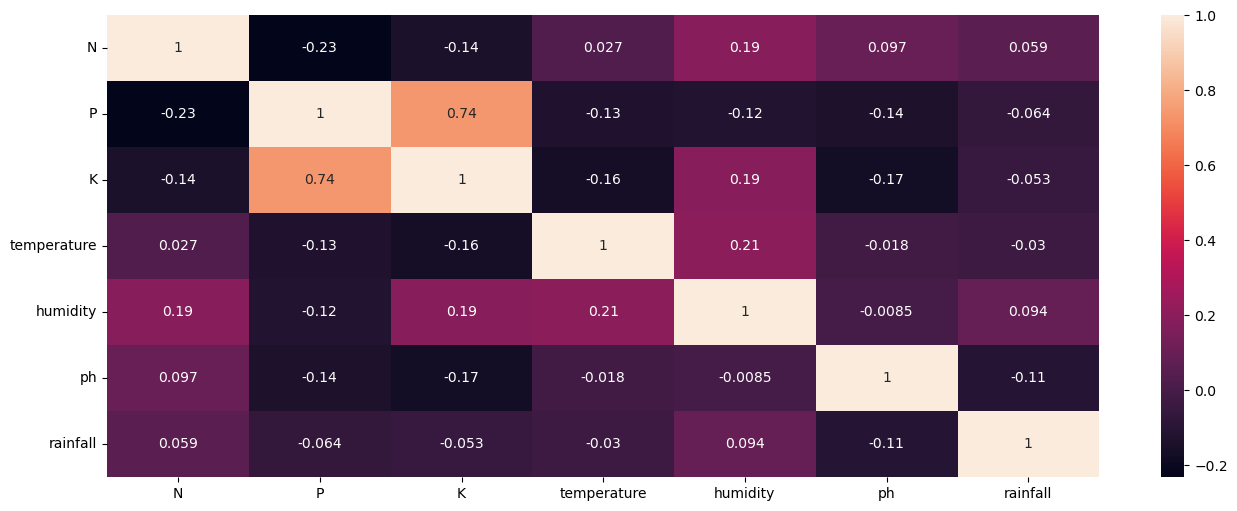

In [9]:
plt.figure(figsize=(16,6))
sns.heatmap(data.drop(['label'],axis=1).corr(),annot=True)
#plt.savefig("heatmap.jpg", dpi=1000, bbox_inches="tight")

CPU times: total: 24 s
Wall time: 18.3 s


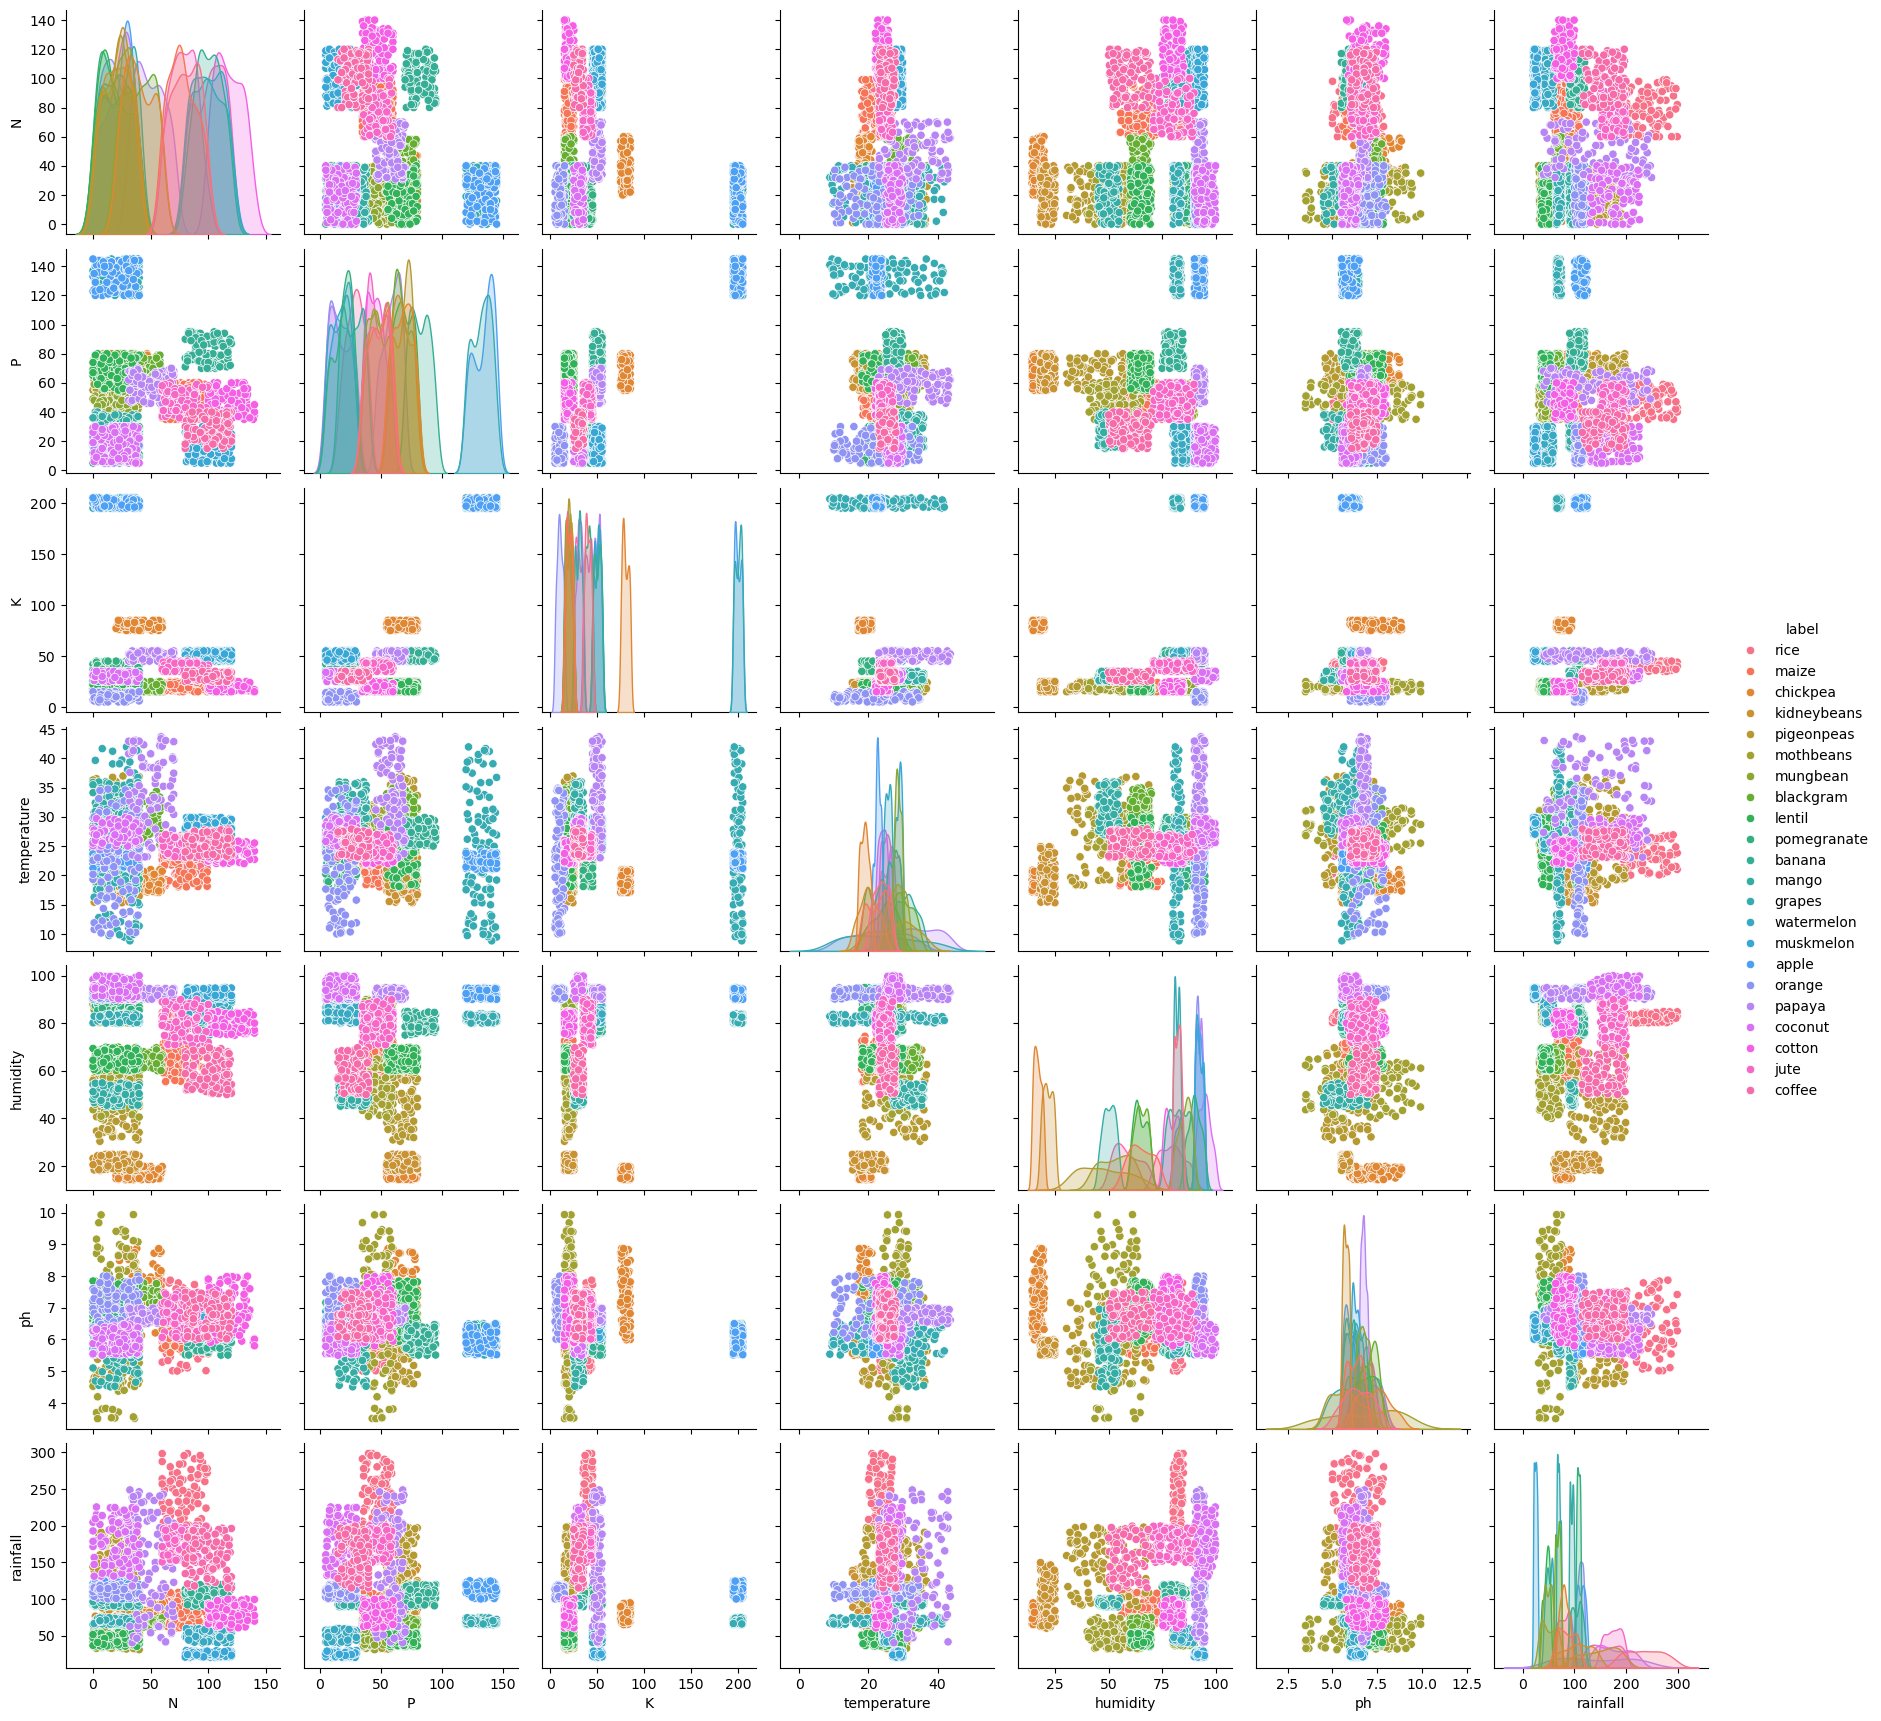

In [10]:
%%time
sns.pairplot(data,hue='label')
plt.savefig("datapairgrid.jpg", dpi=1000, bbox_inches="tight")

## LabelEncoder

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['label'] = le.fit_transform(data['label'])

In [12]:
key_value = dict(zip(le.classes_, le.transform(le.classes_)))
key_value

{'apple': np.int64(0),
 'banana': np.int64(1),
 'blackgram': np.int64(2),
 'chickpea': np.int64(3),
 'coconut': np.int64(4),
 'coffee': np.int64(5),
 'cotton': np.int64(6),
 'grapes': np.int64(7),
 'jute': np.int64(8),
 'kidneybeans': np.int64(9),
 'lentil': np.int64(10),
 'maize': np.int64(11),
 'mango': np.int64(12),
 'mothbeans': np.int64(13),
 'mungbean': np.int64(14),
 'muskmelon': np.int64(15),
 'orange': np.int64(16),
 'papaya': np.int64(17),
 'pigeonpeas': np.int64(18),
 'pomegranate': np.int64(19),
 'rice': np.int64(20),
 'watermelon': np.int64(21)}

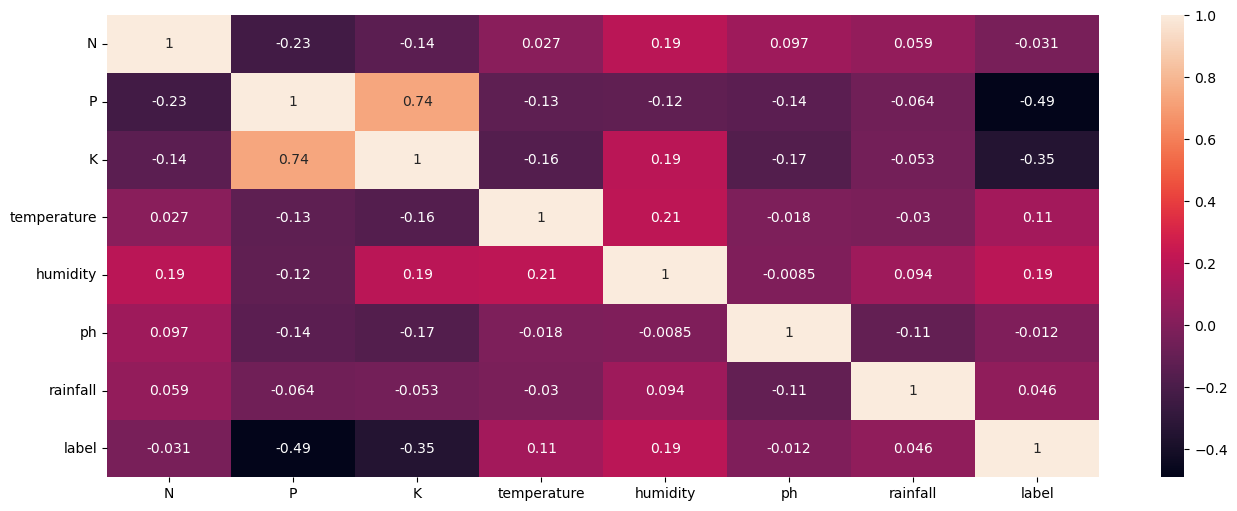

In [13]:
plt.figure(figsize=(16,6))
sns.heatmap(data.corr(),annot=True)
plt.savefig("heatmap.jpg", dpi=1000, bbox_inches="tight")

CPU times: total: 10.1 s
Wall time: 5.91 s


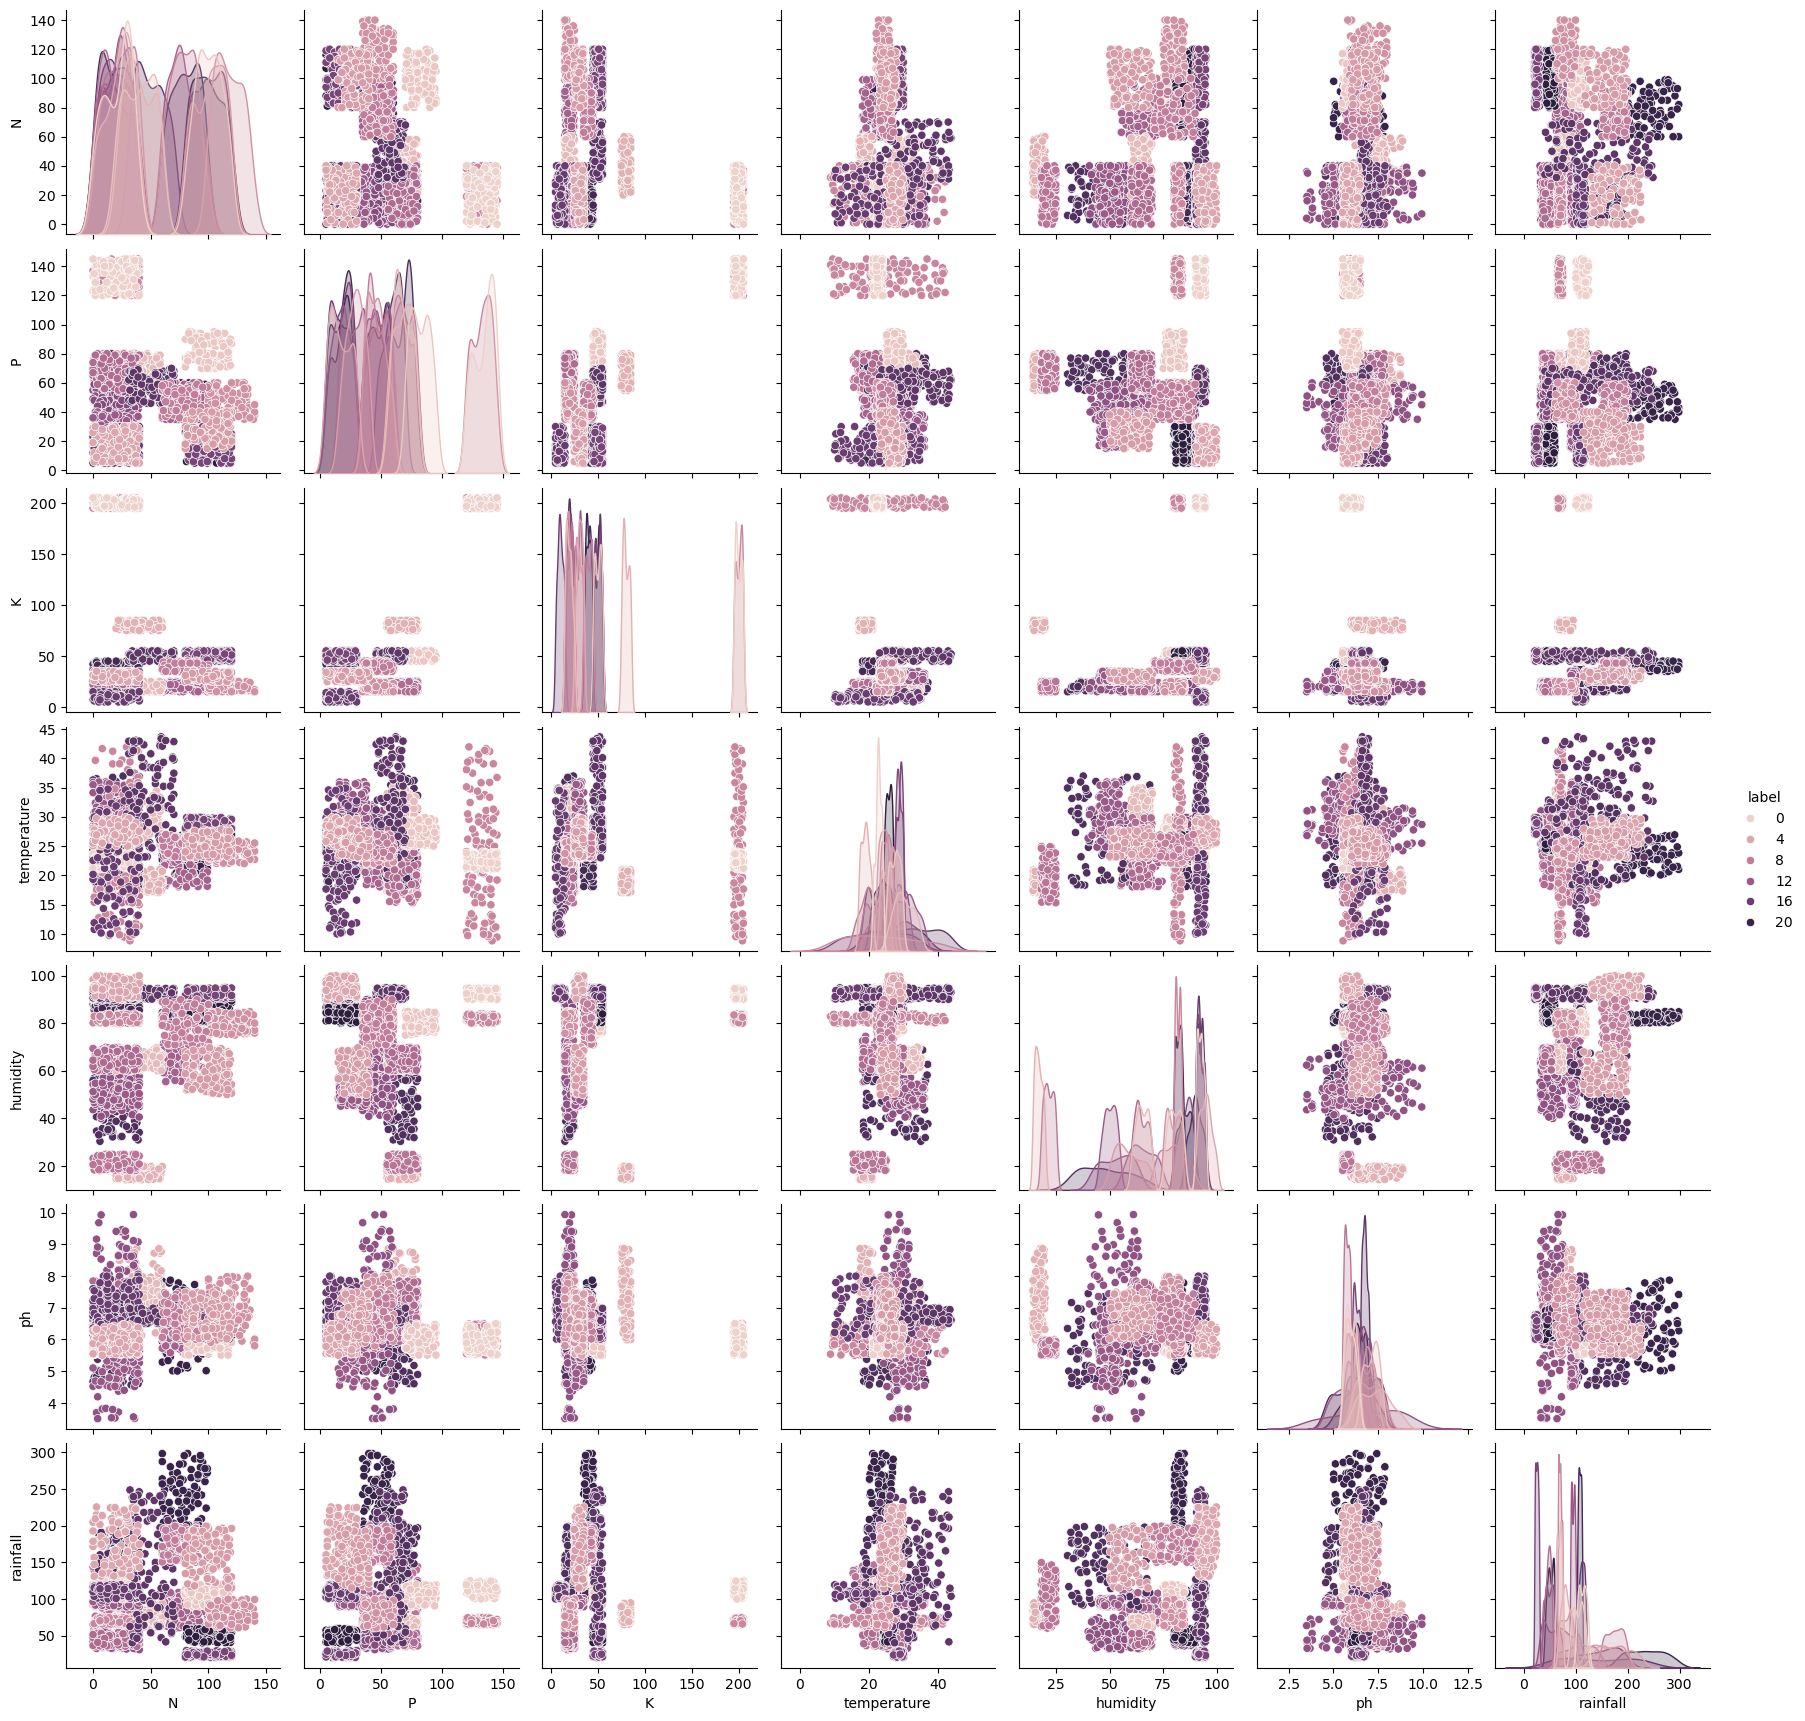

In [14]:
%%time
sns.pairplot(data,hue='label')

## creating in and out features

In [15]:
features=data.drop(['label'],axis=1)
features

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [16]:
target=pd.DataFrame(data.label)
target

,label
0,20
1,20
2,20
3,20
4,20
...,...
2195,5
2196,5
2197,5
2198,5


# model training 

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier, GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [18]:
xtrain, xtest, ytrain, ytest = train_test_split(features, target, test_size=0.2, random_state=42)

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [20]:
import joblib
import warnings

In [21]:
model_results = pd.DataFrame(columns=[
"Model","Train_Acc","Test_Acc",
"Train_Prec","Test_Prec",
"Train_Rec","Test_Rec",
"Train_F1","Test_F1" ])

In [22]:
def clasicalmodels(model,model_name,xtrain=xtrain,ytrain=ytrain,xtest=xtest,ytest=ytest):
    warnings.filterwarnings('ignore')
    model.fit(xtrain, ytrain)
    warnings.filterwarnings('ignore')
    ypred_train = model.predict(xtrain)
    ypred_test = model.predict(xtest)
    print(model,':')

    tr_acc = accuracy_score(ytrain, ypred_train)
    te_acc = accuracy_score(ytest, ypred_test)
    tr_p = precision_score(ytrain, ypred_train, average="weighted")
    te_p = precision_score(ytest, ypred_test, average="weighted")
    tr_r = recall_score(ytrain, ypred_train, average="weighted")
    te_r = recall_score(ytest, ypred_test, average="weighted")
    tr_f = f1_score(ytrain, ypred_train, average="weighted")
    te_f = f1_score(ytest, ypred_test, average="weighted")
    
    print(f"Train Accuracy : {tr_acc:.4f}")
    print(f"Test  Accuracy : {te_acc:.4f}")
    print(f"Train Precision: {tr_p:.4f}")
    print(f"Test  Precision: {te_p:.4f}")
    print(f"Train Recall   : {tr_r:.4f}")
    print(f"Test  Recall   : {te_r:.4f}")    
    print(f"Train F1 Score : {tr_f:.4f}")
    print(f"Test  F1 Score : {te_f:.4f}")

    model_results.loc[len(model_results)] = [model_name,tr_acc,te_acc,tr_p, te_p, tr_r, te_r, tr_f, te_f]

    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    sns.heatmap(confusion_matrix(ytrain, ypred_train),annot=True, fmt='d', ax=axes[0], cmap="Blues", cbar=False)
    axes[0].set_title("Train Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    
    sns.heatmap(confusion_matrix(ytest, ypred_test),annot=True, fmt='d', ax=axes[1], cmap="Blues", cbar=False)
    axes[1].set_title("Test Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    plt.show()
        
    from pathlib import Path
    root=Path("models")
    root.mkdir(exist_ok=True)
    path = root / f"{str(model.__class__.__name__)}.pkl"
    joblib.dump(model, path)

    return model
        

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,
                       random_state=42) :
Train Accuracy : 0.8858
Test  Accuracy : 0.8659
Train Precision: 0.8395
Test  Precision: 0.8212
Train Recall   : 0.8858
Test  Recall   : 0.8659
Train F1 Score : 0.8533
Test  F1 Score : 0.8324


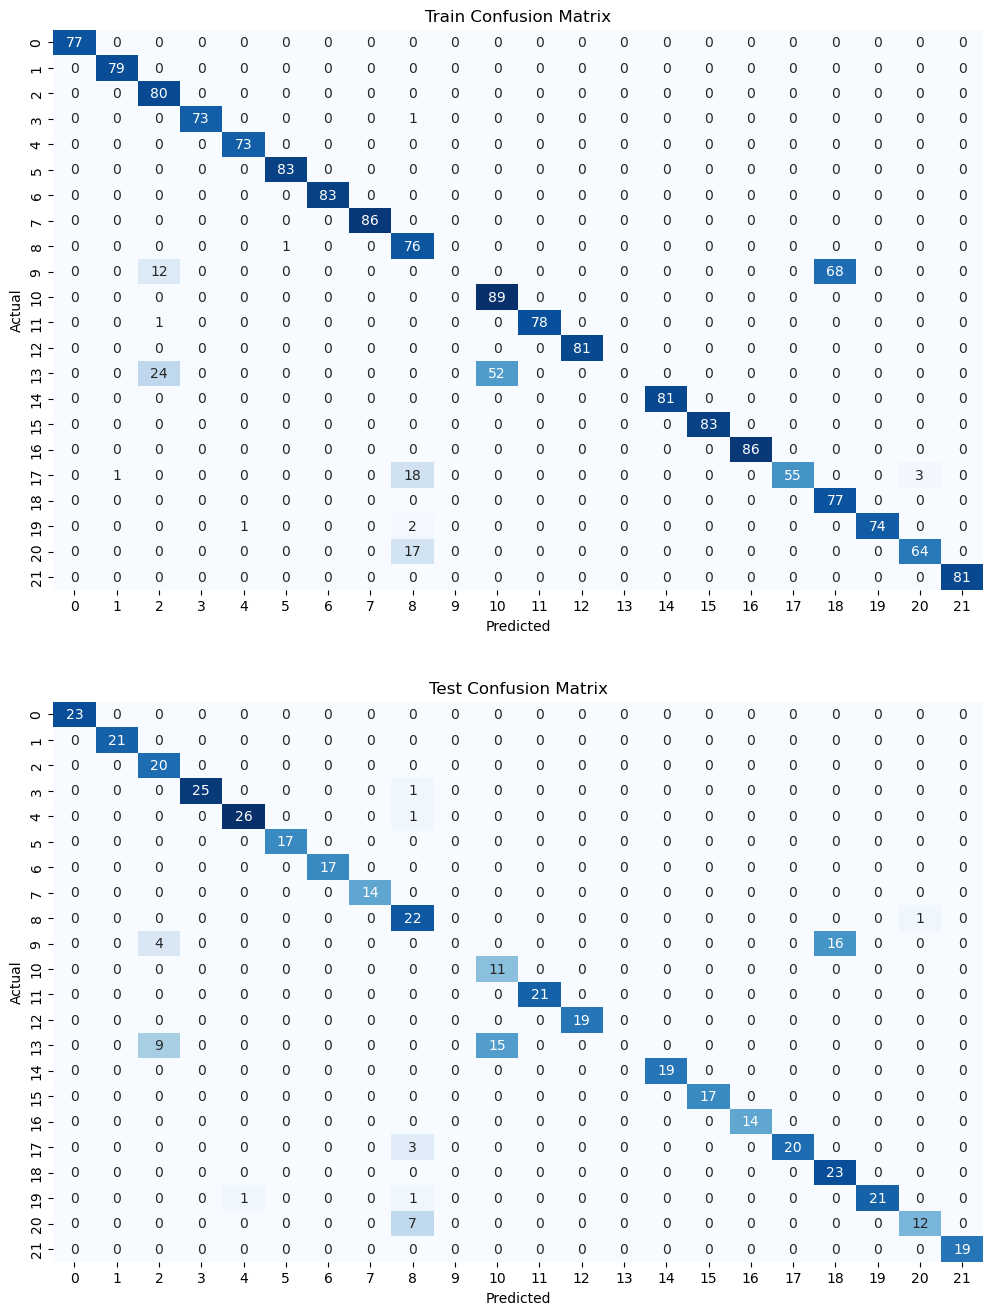

CPU times: total: 781 ms
Wall time: 800 ms


In [23]:
%%time
# DecisionTreeClassifier
decitree=clasicalmodels(DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,random_state=42),model_name='DTC')

RandomForestClassifier(n_estimators=18, random_state=86) :
Train Accuracy : 1.0000
Test  Accuracy : 0.9932
Train Precision: 1.0000
Test  Precision: 0.9937
Train Recall   : 1.0000
Test  Recall   : 0.9932
Train F1 Score : 1.0000
Test  F1 Score : 0.9932


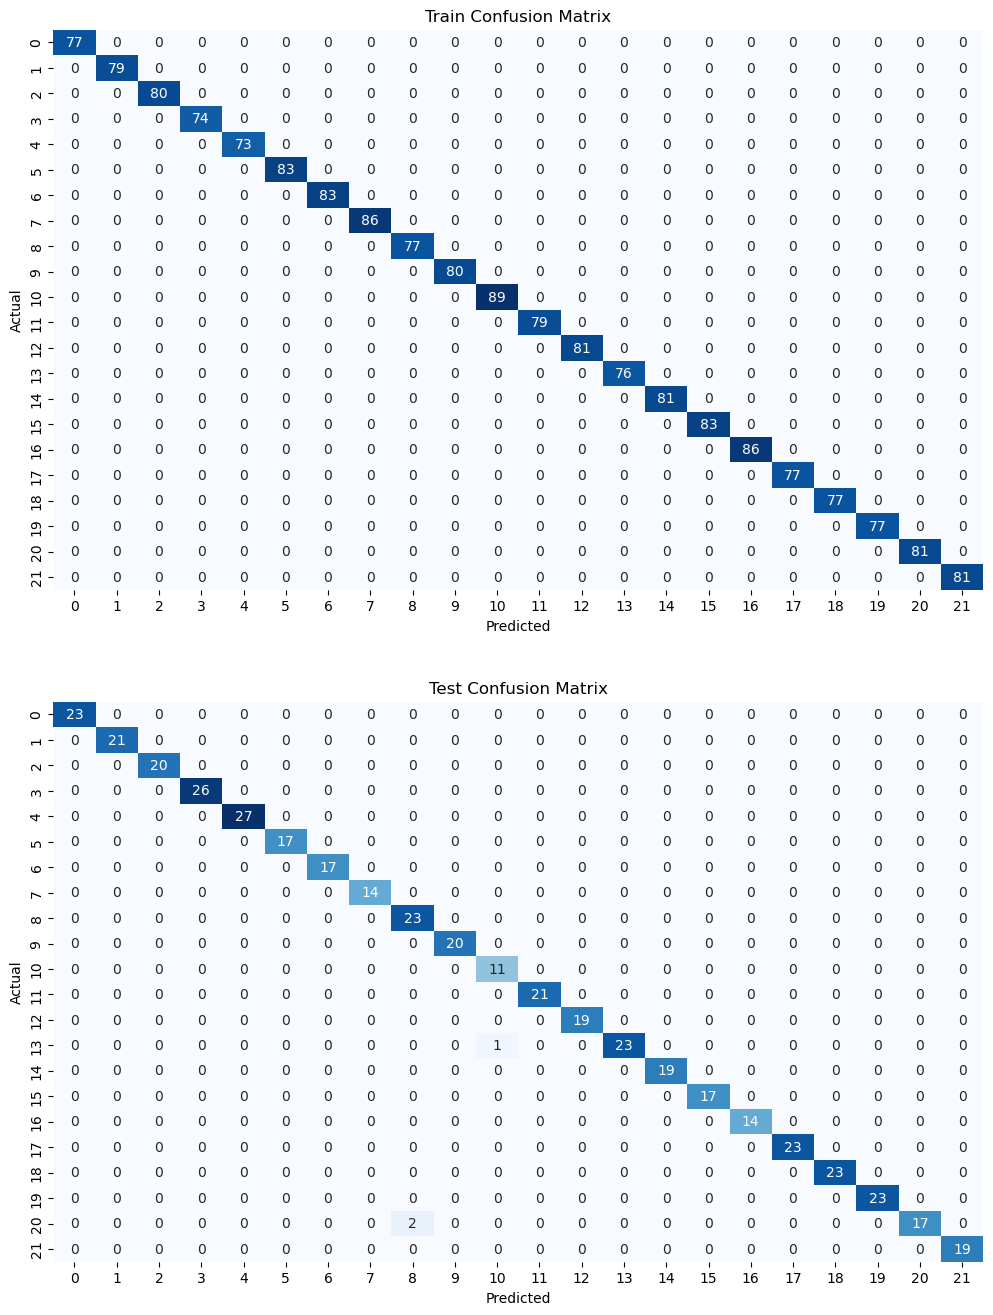

CPU times: total: 1.02 s
Wall time: 1.04 s


In [24]:
%%time
# RandomForestClassifier
warnings.filterwarnings('ignore')
ranfor=clasicalmodels(RandomForestClassifier(n_estimators=18,random_state=86),model_name='RFC')

LogisticRegression(max_iter=5000, random_state=86) :
Train Accuracy : 0.9926
Test  Accuracy : 0.9727
Train Precision: 0.9928
Test  Precision: 0.9735
Train Recall   : 0.9926
Test  Recall   : 0.9727
Train F1 Score : 0.9926
Test  F1 Score : 0.9726


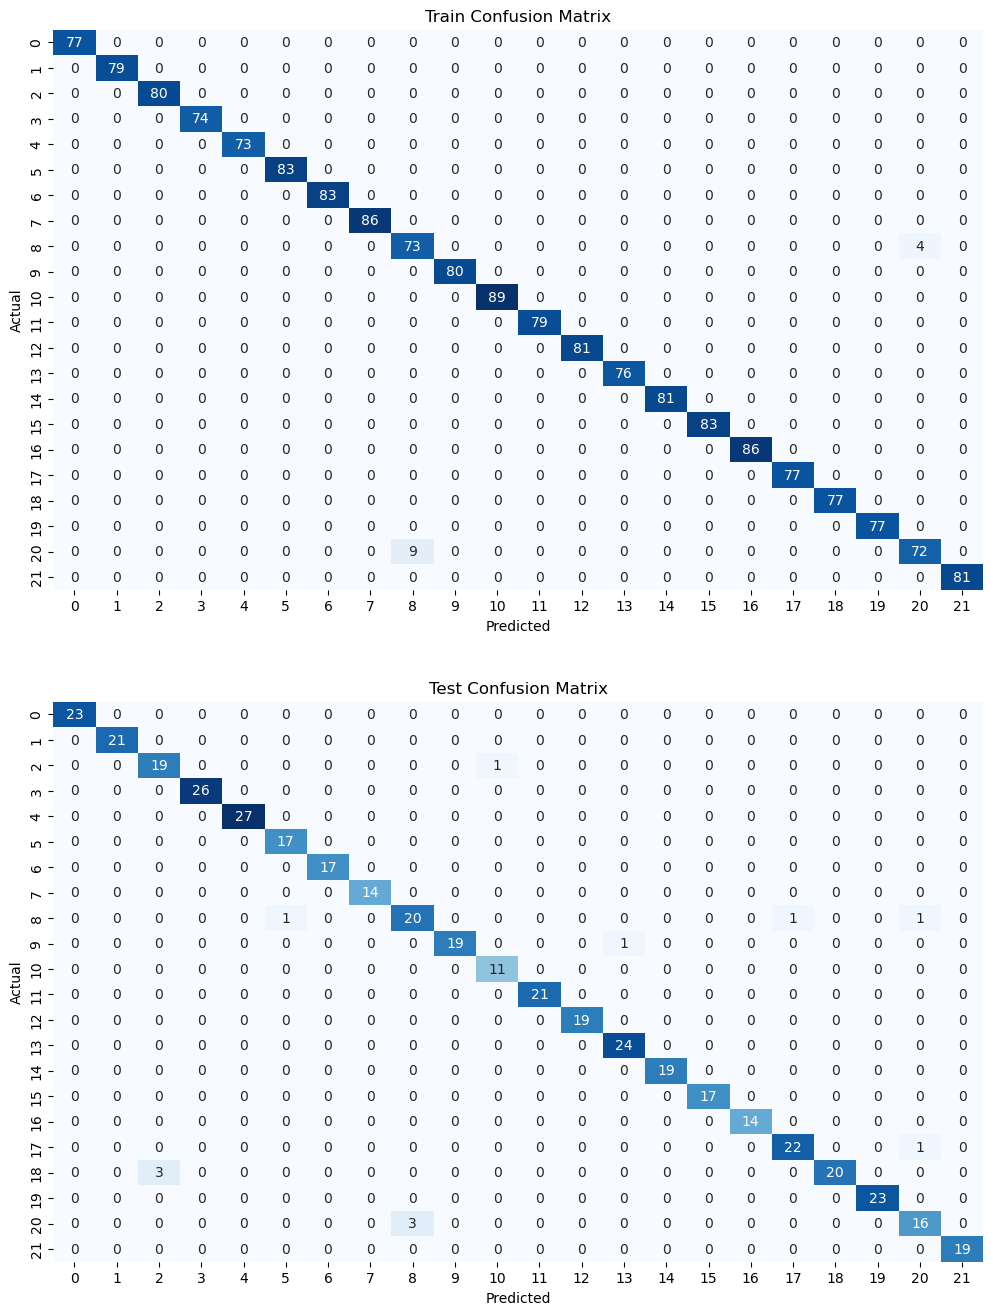

CPU times: total: 25.5 s
Wall time: 3.8 s


In [25]:
%%time
# LogisticRegression
warnings.filterwarnings('ignore')
logcls=clasicalmodels(LogisticRegression(max_iter=5000,random_state=86),model_name='LGR')

KNeighborsClassifier(n_neighbors=6) :
Train Accuracy : 0.9852
Test  Accuracy : 0.9682
Train Precision: 0.9864
Test  Precision: 0.9743
Train Recall   : 0.9852
Test  Recall   : 0.9682
Train F1 Score : 0.9852
Test  F1 Score : 0.9682


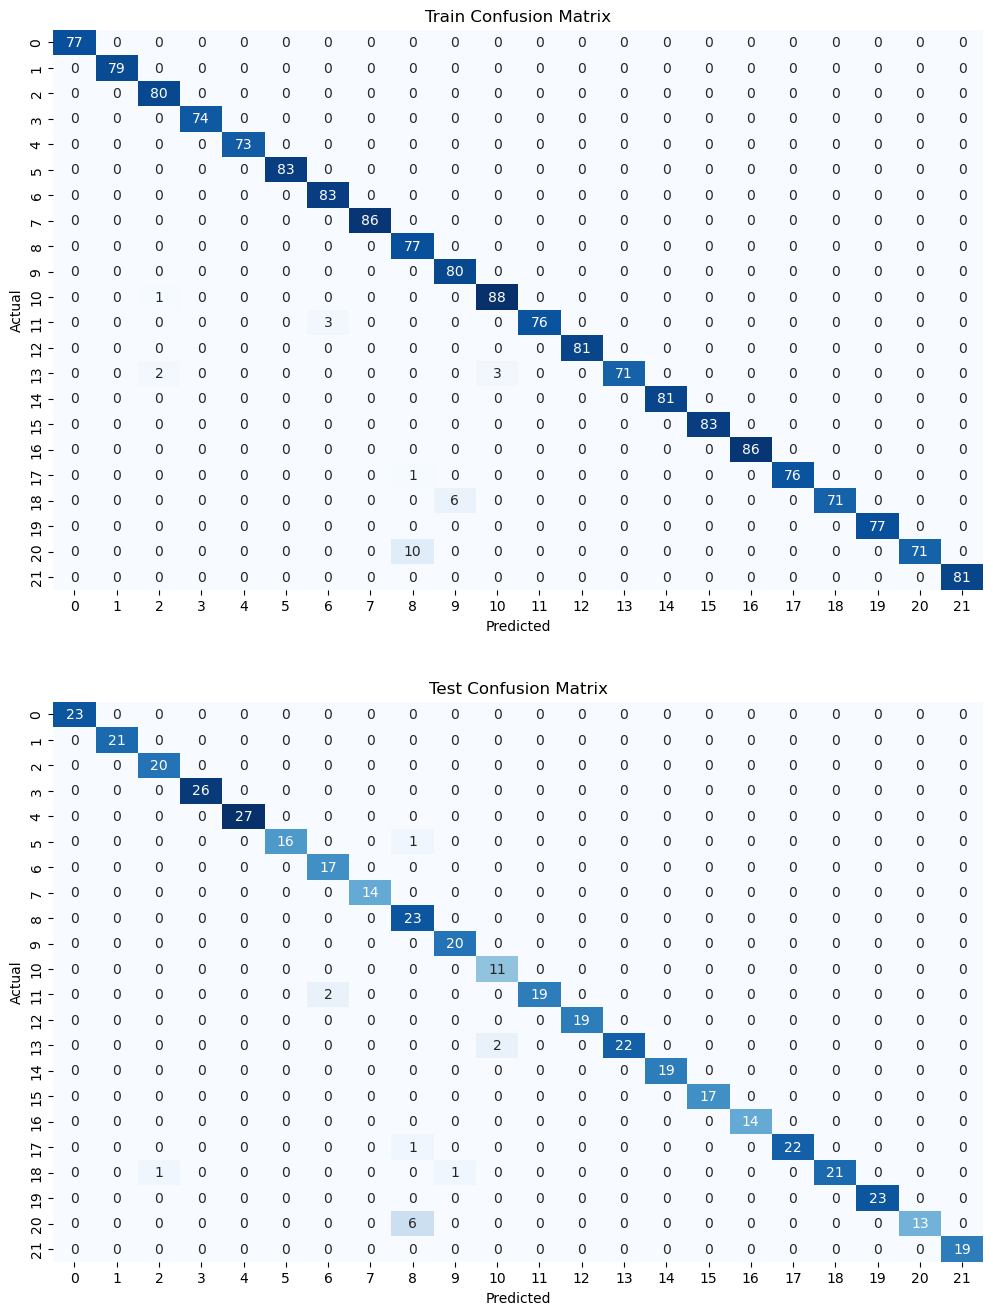

CPU times: total: 875 ms
Wall time: 866 ms


In [26]:
%%time
# KNeighborsClassifier
warnings.filterwarnings('ignore')
knc=clasicalmodels(KNeighborsClassifier(n_neighbors=6),model_name='KNC')
warnings.filterwarnings('ignore')

SVC(C=100, gamma=100, random_state=42) :
Train Accuracy : 1.0000
Test  Accuracy : 0.0250
Train Precision: 1.0000
Test  Precision: 0.0006
Train Recall   : 1.0000
Test  Recall   : 0.0250
Train F1 Score : 1.0000
Test  F1 Score : 0.0012


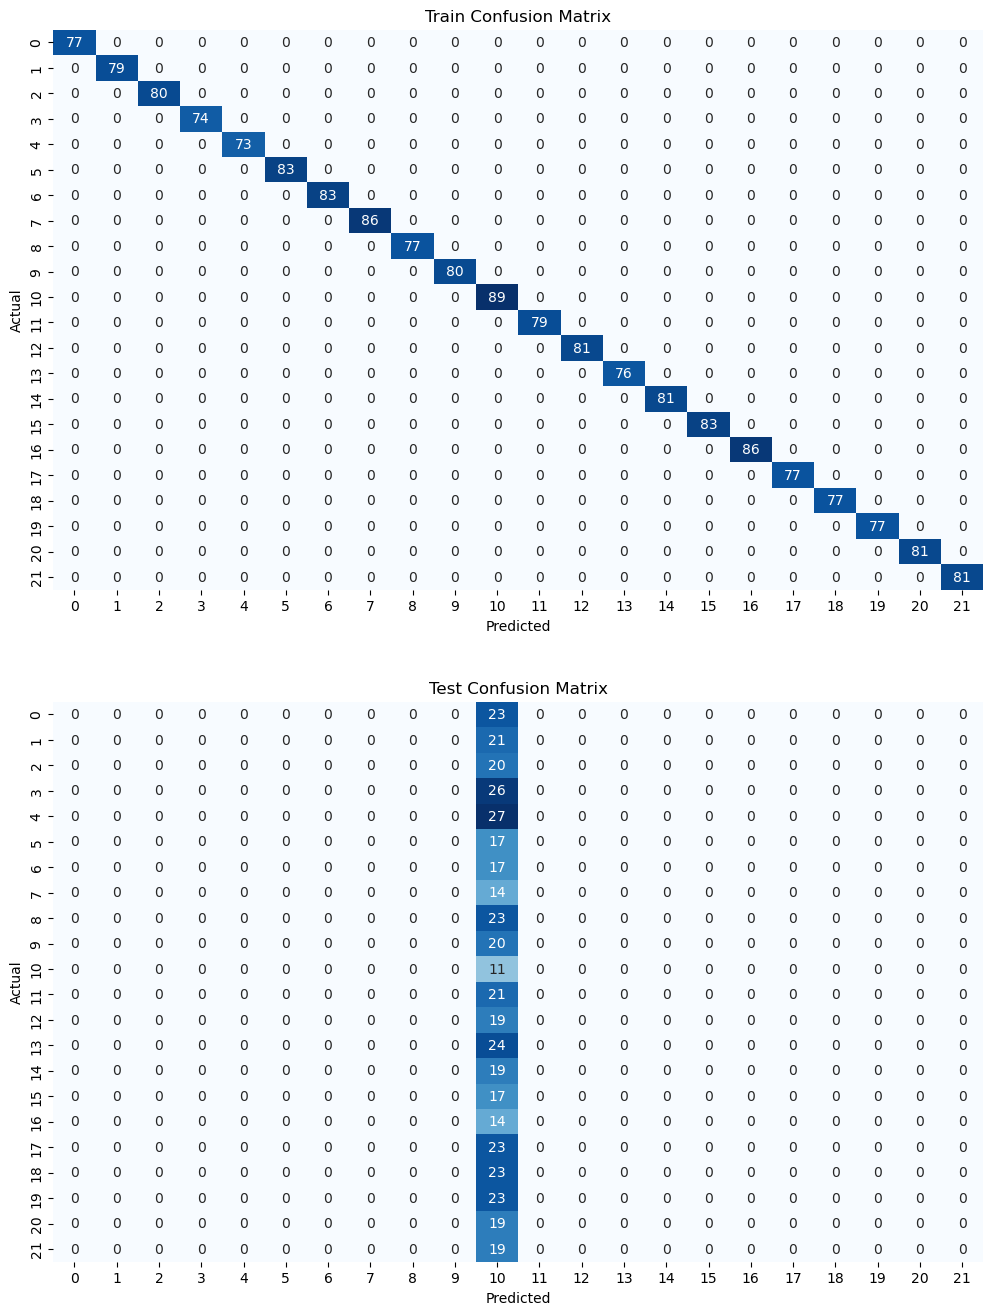

CPU times: total: 1.59 s
Wall time: 1.61 s


In [27]:
%%time
# SVC
warnings.filterwarnings('ignore')
svc=clasicalmodels(SVC(C = 100 ,random_state=42, gamma = 100),model_name='SVC')

GaussianNB() :
Train Accuracy : 0.9949
Test  Accuracy : 0.9955
Train Precision: 0.9950
Test  Precision: 0.9958
Train Recall   : 0.9949
Test  Recall   : 0.9955
Train F1 Score : 0.9949
Test  F1 Score : 0.9954


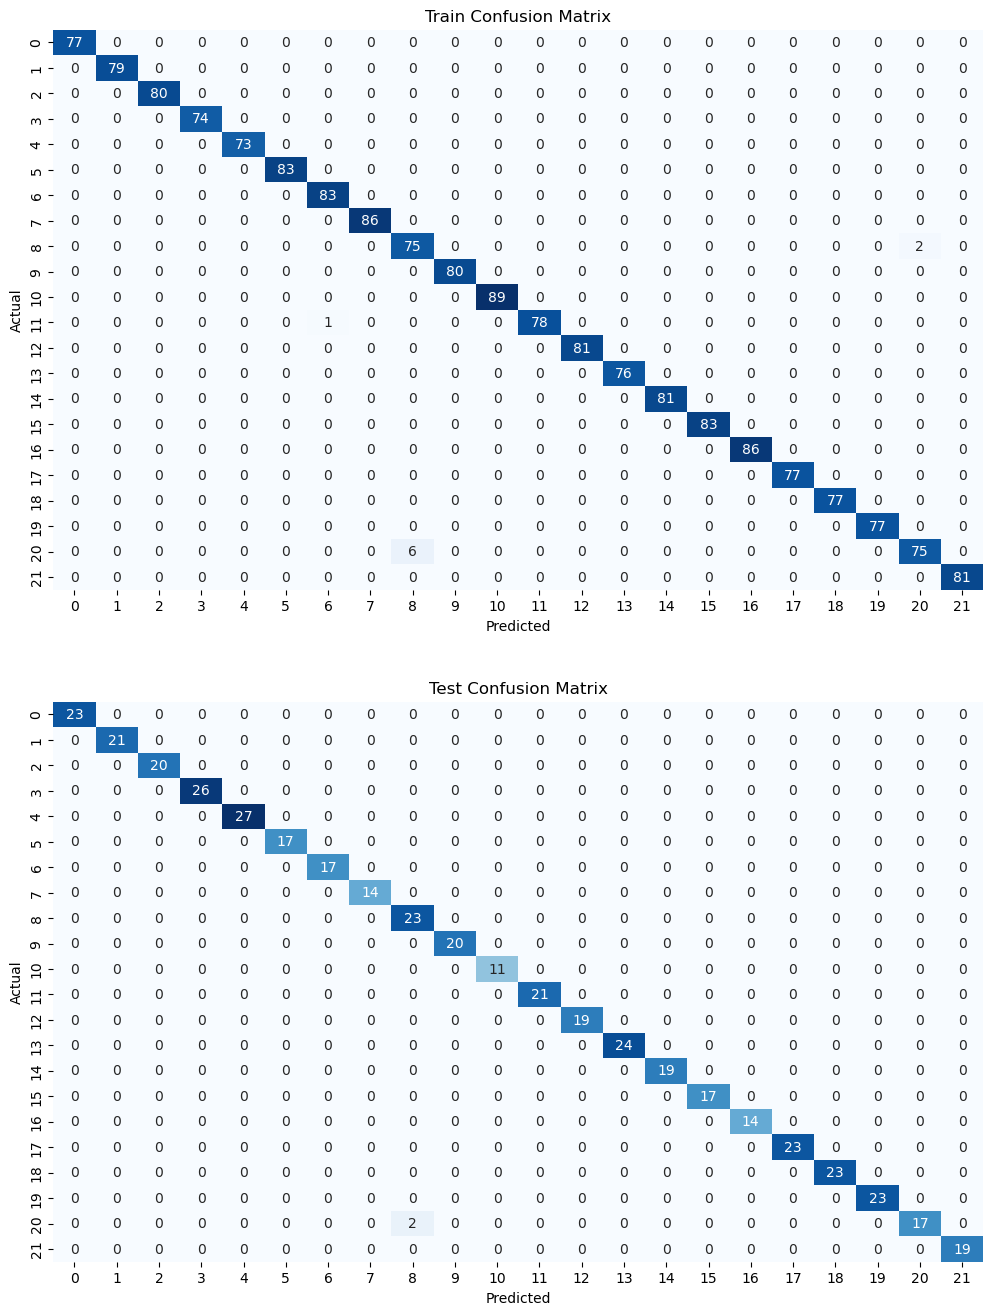

CPU times: total: 828 ms
Wall time: 866 ms


In [28]:
%%time
# GaussianNB
warnings.filterwarnings('ignore')
gauss=clasicalmodels(GaussianNB(),model_name='GNB')

In [29]:
def clasicalmodels(model,pathname,model_name,xtrain=xtrain,ytrain=ytrain,xtest=xtest,ytest=ytest):
    model.fit(xtrain, ytrain)
    ypred_train = model.predict(xtrain)
    ypred_test = model.predict(xtest)
    print(model,':')
    
    tr_acc = accuracy_score(ytrain, ypred_train)
    te_acc = accuracy_score(ytest, ypred_test)
    tr_p = precision_score(ytrain, ypred_train, average="weighted")
    te_p = precision_score(ytest, ypred_test, average="weighted")
    tr_r = recall_score(ytrain, ypred_train, average="weighted")
    te_r = recall_score(ytest, ypred_test, average="weighted")
    tr_f = f1_score(ytrain, ypred_train, average="weighted")
    te_f = f1_score(ytest, ypred_test, average="weighted")
    
    print(f"Train Acc uracy : {tr_acc:.4f}")
    print(f"Test  Accuracy : {te_acc:.4f}")
    print(f"Train Precision: {tr_p:.4f}")
    print(f"Test  Precision: {te_p:.4f}")
    print(f"Train Recall   : {tr_r:.4f}")
    print(f"Test  Recall   : {te_r:.4f}")    
    print(f"Train F1 Score : {tr_f:.4f}")
    print(f"Test  F1 Score : {te_f:.4f}")

    model_results.loc[len(model_results)] = [model_name,tr_acc,te_acc,tr_p, te_p, tr_r, te_r, tr_f, te_f]


    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    sns.heatmap(confusion_matrix(ytrain, ypred_train),annot=True, fmt='d', ax=axes[0], cmap="Blues", cbar=False)
    axes[0].set_title("Train Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    
    sns.heatmap(confusion_matrix(ytest, ypred_test),annot=True, fmt='d', ax=axes[1], cmap="Blues", cbar=False)
    axes[1].set_title("Test Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    plt.show()
        
    from pathlib import Path
    root=Path("models")
    root.mkdir(exist_ok=True)
    path = root / f"{str(pathname)}.pkl"
    joblib.dump(model, path)

    return model
        

GradientBoostingClassifier(max_depth=6, random_state=42) :
Train Acc uracy : 1.0000
Test  Accuracy : 0.9795
Train Precision: 1.0000
Test  Precision: 0.9813
Train Recall   : 1.0000
Test  Recall   : 0.9795
Train F1 Score : 1.0000
Test  F1 Score : 0.9795


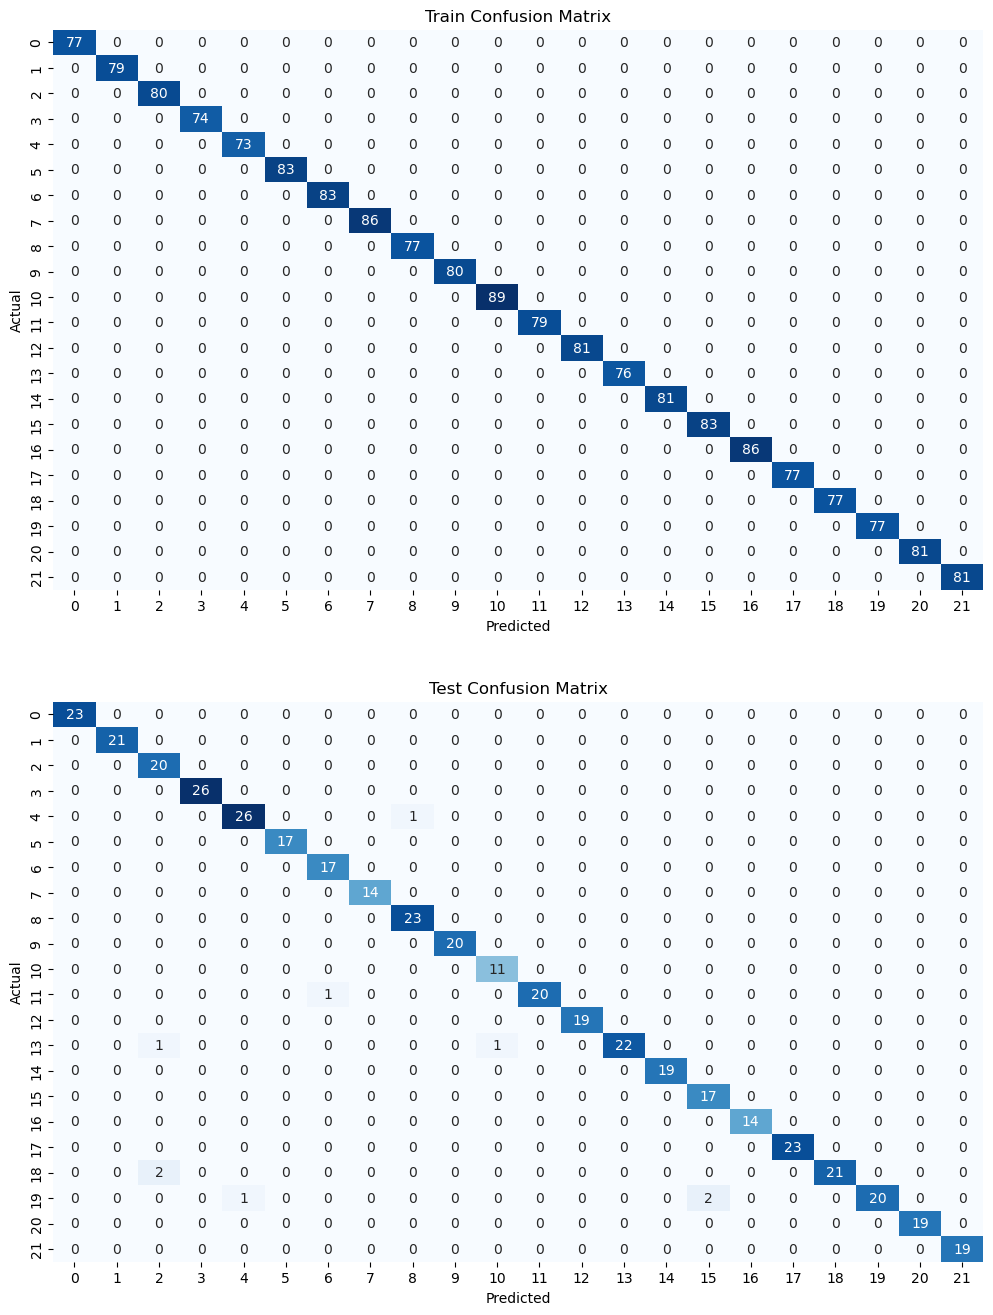

CPU times: total: 10.7 s
Wall time: 10.8 s


In [30]:
%%time
# GradientBoostingClassifier
warnings.filterwarnings('ignore')
gradc=clasicalmodels(GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42)
,'GradientBoostingClassifier',model_name='GBC')

AdaBoostClassifier(learning_rate=0.5, n_estimators=25, random_state=42) :
Train Acc uracy : 0.2324
Test  Accuracy : 0.1864
Train Precision: 0.1485
Test  Precision: 0.1043
Train Recall   : 0.2324
Test  Recall   : 0.1864
Train F1 Score : 0.1639
Test  F1 Score : 0.1193


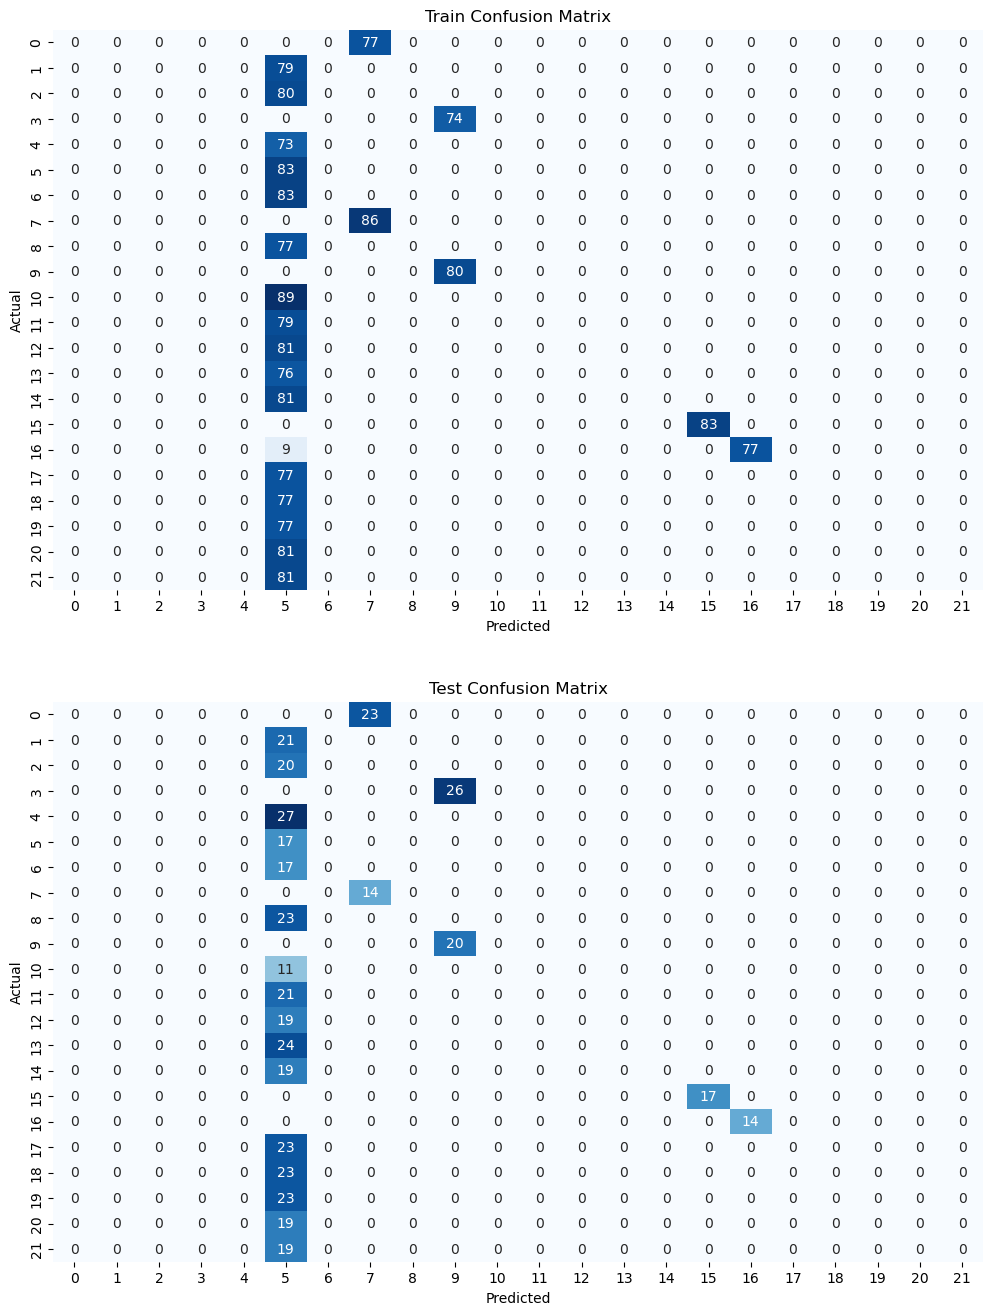

CPU times: total: 1.33 s
Wall time: 1.37 s


In [31]:
%%time
# AdaBoostClassifier
warnings.filterwarnings('ignore')
adaboost=clasicalmodels(AdaBoostClassifier(n_estimators=25,learning_rate=0.5,random_state=42),'AdaBoostClassifier',model_name='ABC')

LinearDiscriminantAnalysis() :
Train Acc uracy : 0.9739
Test  Accuracy : 0.9432
Train Precision: 0.9760
Test  Precision: 0.9529
Train Recall   : 0.9739
Test  Recall   : 0.9432
Train F1 Score : 0.9738
Test  F1 Score : 0.9426


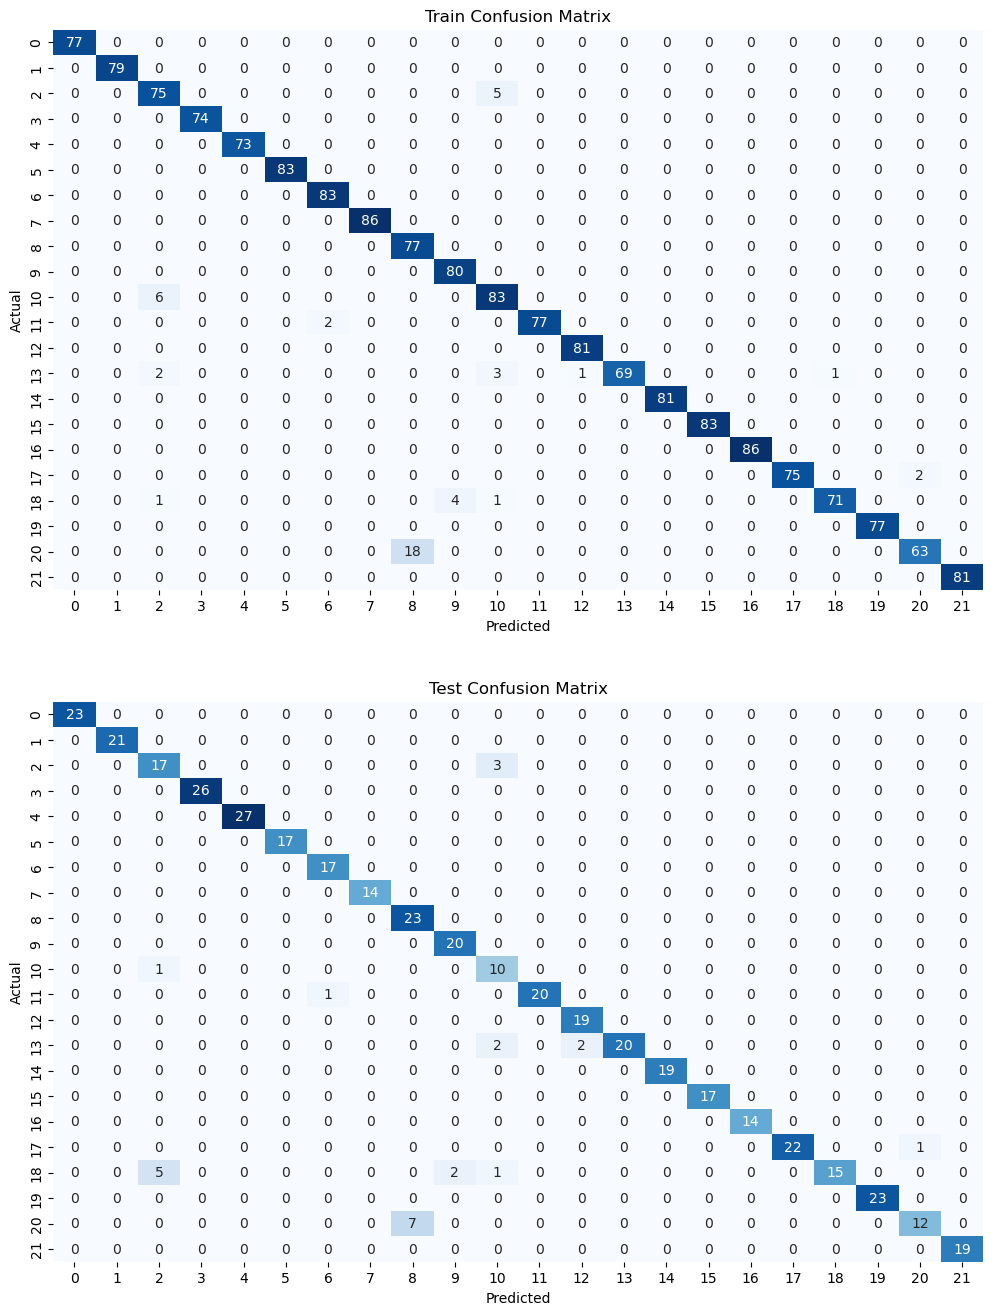

CPU times: total: 2.39 s
Wall time: 995 ms


In [32]:
%%time
# LinearDiscriminantAnalysis
warnings.filterwarnings('ignore')
bag_gauss=clasicalmodels(LinearDiscriminantAnalysis(),'LinearDiscriminantAnalysis',model_name='LDA')

In [33]:
model_results

,Model,Train_Acc,Test_Acc,Train_Prec,Test_Prec,Train_Rec,Test_Rec,Train_F1,Test_F1
0,DTC,0.885795,0.865909,0.839496,0.821215,0.885795,0.865909,0.853261,0.832359
1,RFC,1.000000,0.993182,1.000000,0.993735,1.000000,0.993182,1.000000,0.993175
2,LGR,0.992614,0.972727,0.992776,0.973501,0.992614,0.972727,0.992612,0.972628
3,KNC,0.985227,0.968182,0.986405,0.974268,0.985227,0.968182,0.985218,0.968246
4,SVC,1.000000,0.025000,1.000000,0.000625,1.000000,0.025000,1.000000,0.001220
5,GNB,0.994886,0.995455,0.995002,0.995818,0.994886,0.995455,0.994886,0.995423
6,GBC,1.000000,0.979545,1.000000,0.981324,1.000000,0.979545,1.000000,0.979548
7,ABC,0.232386,0.186364,0.148467,0.104271,0.232386,0.186364,0.163889,0.119301
8,LDA,0.973864,0.943182,0.976034,0.952857,0.973864,0.943182,0.973802,0.942589


In [34]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [35]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## FNN

In [36]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(7, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(),

            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),

            nn.Linear(256, 128),
            nn.LeakyReLU(),

            nn.Linear(128, 64),
            nn.LeakyReLU(),

            nn.Linear(64, 22)
        )

    def forward(self, x):
        return self.net(x)

In [37]:
FNN_model = FFN()
FNN_model.to(device)

FFN(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Linear(in_features=1024, out_features=2048, bias=True)
    (10): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.01)
    (12): Linear(in_features=2048, out_features=1024, bias=True)
    (13): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReLU(negative_slope=0.01)
   

In [38]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values.squeeze(), dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [39]:
train_dataset = CustomDataset(xtrain,ytrain)

In [40]:
test_dataset = CustomDataset(xtest,ytest)

In [41]:
train_dataloader = DataLoader(train_dataset, batch_size=50, shuffle=True)

In [42]:
test_dataloader = DataLoader(test_dataset, batch_size=50, shuffle=True)

In [43]:
def accuracy_fn(y_true, y_pred):
    return (y_true == y_pred).sum().item() / len(y_true)

In [44]:
def train(model, epochs, train_dataloader=train_dataloader, device=device):
    torch.cuda.manual_seed_all(33)

    for epoch in range(epochs):
        model.train()
        avg_loss = 0.0
        avg_acc  = 0.0

        for step, (x, y) in enumerate(train_dataloader):
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(x)  # shape: [B, 10]
            loss = loss_fn(logits, y)      # y: [B] with 0/1

            loss.backward()
            optimizer.step()

            preds = logits.argmax(dim=1)   # NO softmax
            acc = accuracy_fn(y, preds)

            avg_loss += loss.item()
            avg_acc  += acc

        avg_loss /= (step + 1)
        avg_acc  /= (step + 1)

        print(f"Epoch {epoch} | Avg Loss {avg_loss:.4f} | Avg Acc {avg_acc:.4f}")


In [45]:
loss_fn = nn.CrossEntropyLoss()  
optimizer = torch.optim.Adam(FNN_model.parameters(), lr=0.0001)

In [46]:
train(model=FNN_model,epochs=300)

Epoch 0 | Avg Loss 2.6818 | Avg Acc 0.6139
Epoch 1 | Avg Loss 2.1603 | Avg Acc 0.8833
Epoch 2 | Avg Loss 1.6722 | Avg Acc 0.9178
Epoch 3 | Avg Loss 1.2241 | Avg Acc 0.9422
Epoch 4 | Avg Loss 0.8424 | Avg Acc 0.9544
Epoch 5 | Avg Loss 0.5774 | Avg Acc 0.9461
Epoch 6 | Avg Loss 0.4237 | Avg Acc 0.9489
Epoch 7 | Avg Loss 0.3219 | Avg Acc 0.9544
Epoch 8 | Avg Loss 0.3101 | Avg Acc 0.9394
Epoch 9 | Avg Loss 0.2501 | Avg Acc 0.9556
Epoch 10 | Avg Loss 0.2164 | Avg Acc 0.9528
Epoch 11 | Avg Loss 0.1661 | Avg Acc 0.9639
Epoch 12 | Avg Loss 0.1774 | Avg Acc 0.9561
Epoch 13 | Avg Loss 0.1626 | Avg Acc 0.9650
Epoch 14 | Avg Loss 0.1837 | Avg Acc 0.9550
Epoch 15 | Avg Loss 0.1291 | Avg Acc 0.9672
Epoch 16 | Avg Loss 0.1866 | Avg Acc 0.9528
Epoch 17 | Avg Loss 0.1375 | Avg Acc 0.9622
Epoch 18 | Avg Loss 0.0924 | Avg Acc 0.9739
Epoch 19 | Avg Loss 0.0917 | Avg Acc 0.9794
Epoch 20 | Avg Loss 0.1249 | Avg Acc 0.9622
Epoch 21 | Avg Loss 0.1611 | Avg Acc 0.9561
Epoch 22 | Avg Loss 0.1559 | Avg Acc 0.961

In [47]:
xtrain = torch.tensor(xtrain.values, dtype=torch.float32)
xtest  = torch.tensor(xtest.values,  dtype=torch.float32)
ytrain = torch.tensor(ytrain.values, dtype=torch.long)
ytest  = torch.tensor(ytest.values,  dtype=torch.long)

In [48]:
xtrain = xtrain.to(device)
ytrain = ytrain.to(device)
xtest = xtest.to(device)
ytest = ytest.to(device)


In [49]:
def accuracy_full(model, loader, device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [50]:
accuracy_full(FNN_model, train_dataloader, 'cuda')

0.9948863636363636

In [51]:
print("Train batches:", len(train_dataloader))
print("Test batches:", len(test_dataloader))

Train batches: 36
Test batches: 9


In [53]:
def evaluate_model(model, loader, device):
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            preds = model(x).argmax(1)

            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return {
        "acc": (y_true == y_pred).mean(),
        "precision": precision_score(y_true, y_pred, average="weighted"),
        "recall": recall_score(y_true, y_pred, average="weighted"),
        "f1": f1_score(y_true, y_pred, average="weighted"),
        "cm": confusion_matrix(y_true, y_pred)
    }

In [54]:
def plot_cm_and_store(model, train_loader, test_loader, device, model_results, name="FFN"):
    tr = evaluate_model(model, train_loader, device)
    te = evaluate_model(model, test_loader, device)

    print("Train Accuracy :", tr["acc"])
    print("Test  Accuracy :", te["acc"])
    print("Train Precision:", tr["precision"])
    print("Test  Precision:", te["precision"])
    print("Train Recall   :", tr["recall"])
    print("Test  Recall   :", te["recall"])
    print("Train F1-score :", tr["f1"])
    print("Test  F1-score :", te["f1"])

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    sns.heatmap(tr["cm"], annot=True, fmt="d", ax=ax[0], cbar=False)
    ax[0].set_title(f"Train Acc = {tr['acc']:.3f}")
    sns.heatmap(te["cm"], annot=True, fmt="d", ax=ax[1], cbar=False)
    ax[1].set_title(f"Test Acc = {te['acc']:.3f}")
    plt.tight_layout(); plt.show()

    model_results.loc[len(model_results)] = [
        name,
        tr["acc"], te["acc"],
        tr["precision"], te["precision"],
        tr["recall"], te["recall"],
        tr["f1"], te["f1"]
    ]


Train Accuracy : 0.9948863636363636
Test  Accuracy : 0.9886363636363636
Train Precision: 0.9950541195005252
Test  Precision: 0.9894163059163059
Train Recall   : 0.9948863636363636
Test  Recall   : 0.9886363636363636
Train F1-score : 0.994885339393211
Test  F1-score : 0.9885684809770175


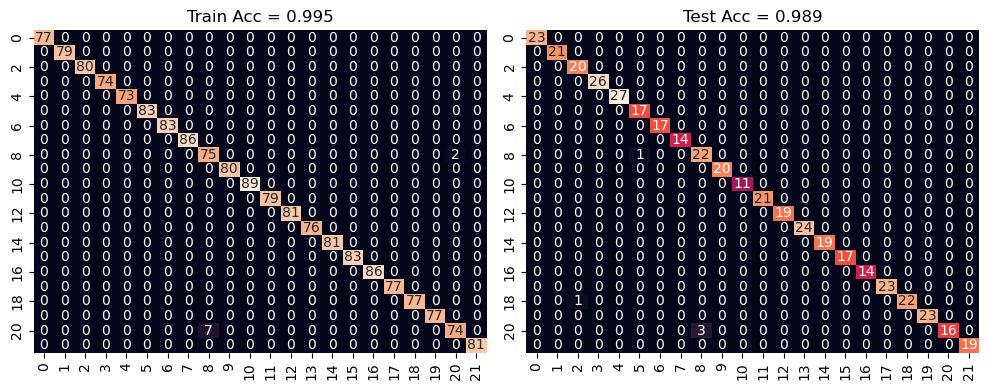

In [55]:
plot_cm_and_store(FNN_model, train_dataloader, test_dataloader, device,model_results)

In [56]:
#model_results = model_results.drop(index=9).reset_index(drop=True)

# Final results

In [57]:
model_results

,Model,Train_Acc,Test_Acc,Train_Prec,Test_Prec,Train_Rec,Test_Rec,Train_F1,Test_F1
0,DTC,0.885795,0.865909,0.839496,0.821215,0.885795,0.865909,0.853261,0.832359
1,RFC,1.000000,0.993182,1.000000,0.993735,1.000000,0.993182,1.000000,0.993175
2,LGR,0.992614,0.972727,0.992776,0.973501,0.992614,0.972727,0.992612,0.972628
3,KNC,0.985227,0.968182,0.986405,0.974268,0.985227,0.968182,0.985218,0.968246
4,SVC,1.000000,0.025000,1.000000,0.000625,1.000000,0.025000,1.000000,0.001220
5,GNB,0.994886,0.995455,0.995002,0.995818,0.994886,0.995455,0.994886,0.995423
6,GBC,1.000000,0.979545,1.000000,0.981324,1.000000,0.979545,1.000000,0.979548
7,ABC,0.232386,0.186364,0.148467,0.104271,0.232386,0.186364,0.163889,0.119301
8,LDA,0.973864,0.943182,0.976034,0.952857,0.973864,0.943182,0.973802,0.942589
9,FFN,0.994886,0.988636,0.995054,0.989416,0.994886,0.988636,0.994885,0.988568


In [58]:
def plot_model_metrics1(df):
    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig, axes = plt.subplots(2, 3, figsize=(32, 20))
    axes = axes.flatten()

    palette_train = ["#88ccee", "#44aa99"]  # soft cyan / turquoise
    palette_test  = ["#ddcc77", "#cc6677"]  # soft mustard / rose
    palette_summary = ["#fb9a99", "#e31a1c", "#fdbf6f"]  # pink / red / peach


    # 1-4
    for i, m in enumerate(metrics):
        df_long = df[['Model', f'Train_{m}', f'Test_{m}']].copy()
        df_long = df_long.melt('Model', var_name='Dataset', value_name='Score')
        df_long['Dataset'] = df_long['Dataset'].apply(lambda x: 'Train' if 'Train' in x else 'Test')

        sns.barplot(x='Model', y='Score', hue='Dataset', data=df_long,
                    palette=[palette_train[0], palette_test[0]], ax=axes[i])
        axes[i].set_title(f'{m} - Train vs Test', fontsize=16)
        axes[i].set_ylim(0, 1.05)
        axes[i].tick_params(axis='x', rotation=30)

    # 5
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })
    summary_train = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                    var_name='Stat', value_name='Score')

    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_train,
                palette=palette_summary, ax=axes[4])
    axes[4].set_title('Train Summary (Max / Min / Avg)', fontsize=16)
    axes[4].set_ylim(0, 1.05)
    for container in axes[4].containers:  # annotate only summary
        axes[4].bar_label(container, fmt="%.3f", padding=3)

    # 6
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })
    summary_test = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                   var_name='Stat', value_name='Score')

    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_test,
                palette=palette_summary, ax=axes[5])
    axes[5].set_title('Test Summary (Max / Min / Avg)', fontsize=16)
    axes[5].set_ylim(0, 1.05)
    for container in axes[5].containers:  # annotate only summary
        axes[5].bar_label(container, fmt="%.3f", padding=3)

    plt.tight_layout()
    plt.savefig("plot_model_metrics1.jpg", dpi=1000, bbox_inches="tight")
    plt.show()


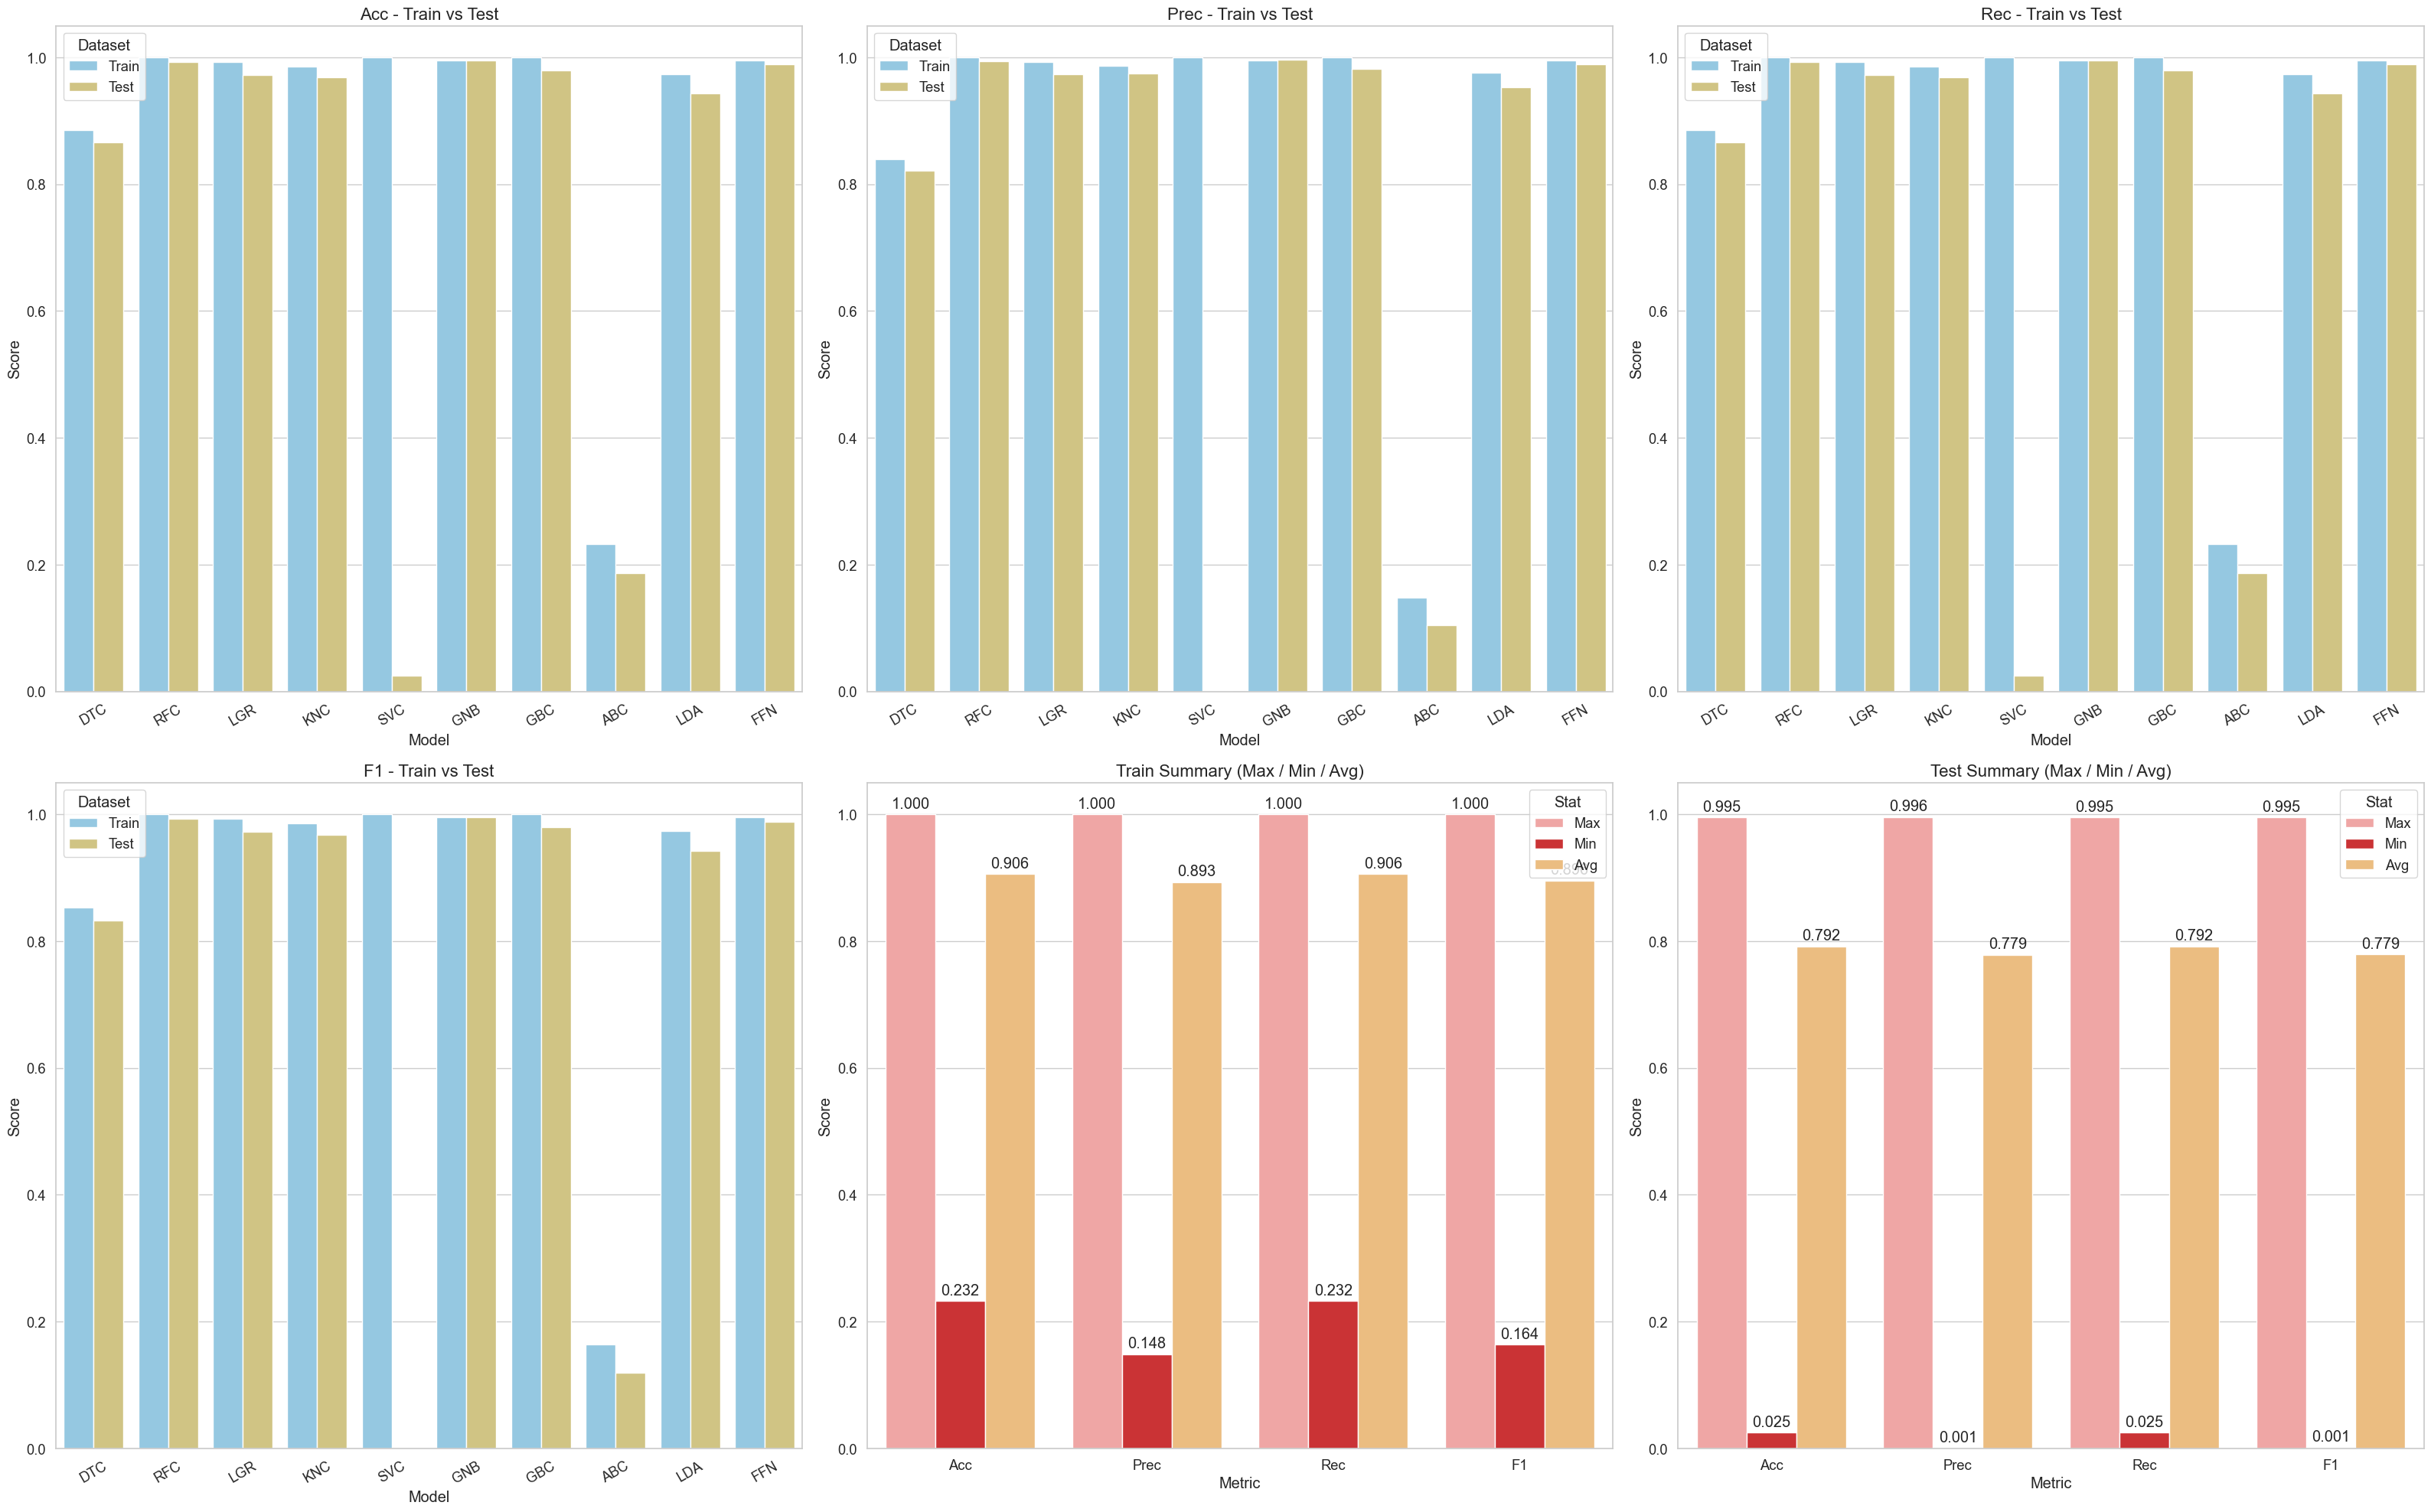

In [59]:
plot_model_metrics1(model_results)

In [60]:
def plot_model_metrics2(df):
    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    palette_train = ["#88ccee", "#44aa99"]      # soft cyan / turquoise
    palette_test  = ["#ddcc77", "#cc6677"]      # soft mustard / rose
    palette_summary = ["#fb9a99", "#e31a1c", "#fdbf6f"]  # pink / red / peach

    # 1-4
    for m in metrics:
        df_long = df[['Model', f'Train_{m}', f'Test_{m}']].copy()
        df_long = df_long.melt('Model', var_name='Dataset', value_name='Score')
        df_long['Dataset'] = df_long['Dataset'].apply(lambda x: 'Train' if 'Train' in x else 'Test')

        plt.figure(figsize=(16, 8))
        sns.barplot(x='Model', y='Score', hue='Dataset', data=df_long,
                    palette=[palette_train[0], palette_test[0]])
        plt.title(f'{m} - Train vs Test', fontsize=18)
        plt.ylim(0, 1.05)
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

    # 5
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })
    summary_train = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                    var_name='Stat', value_name='Score')

    plt.figure(figsize=(16, 8))
    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_train,
                palette=palette_summary)
    plt.title('Train Summary (Max / Min / Avg)', fontsize=18)
    plt.ylim(0, 1.05)
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt="%.3f", padding=3)
    plt.tight_layout()
    plt.show()

    # 6
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })
    summary_test = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                   var_name='Stat', value_name='Score')

    plt.figure(figsize=(16, 8))
    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_test,
                palette=palette_summary)
    plt.title('Test Summary (Max / Min / Avg)', fontsize=18)
    plt.ylim(0, 1.05)
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt="%.3f", padding=3)
    plt.tight_layout()
    plt.show()


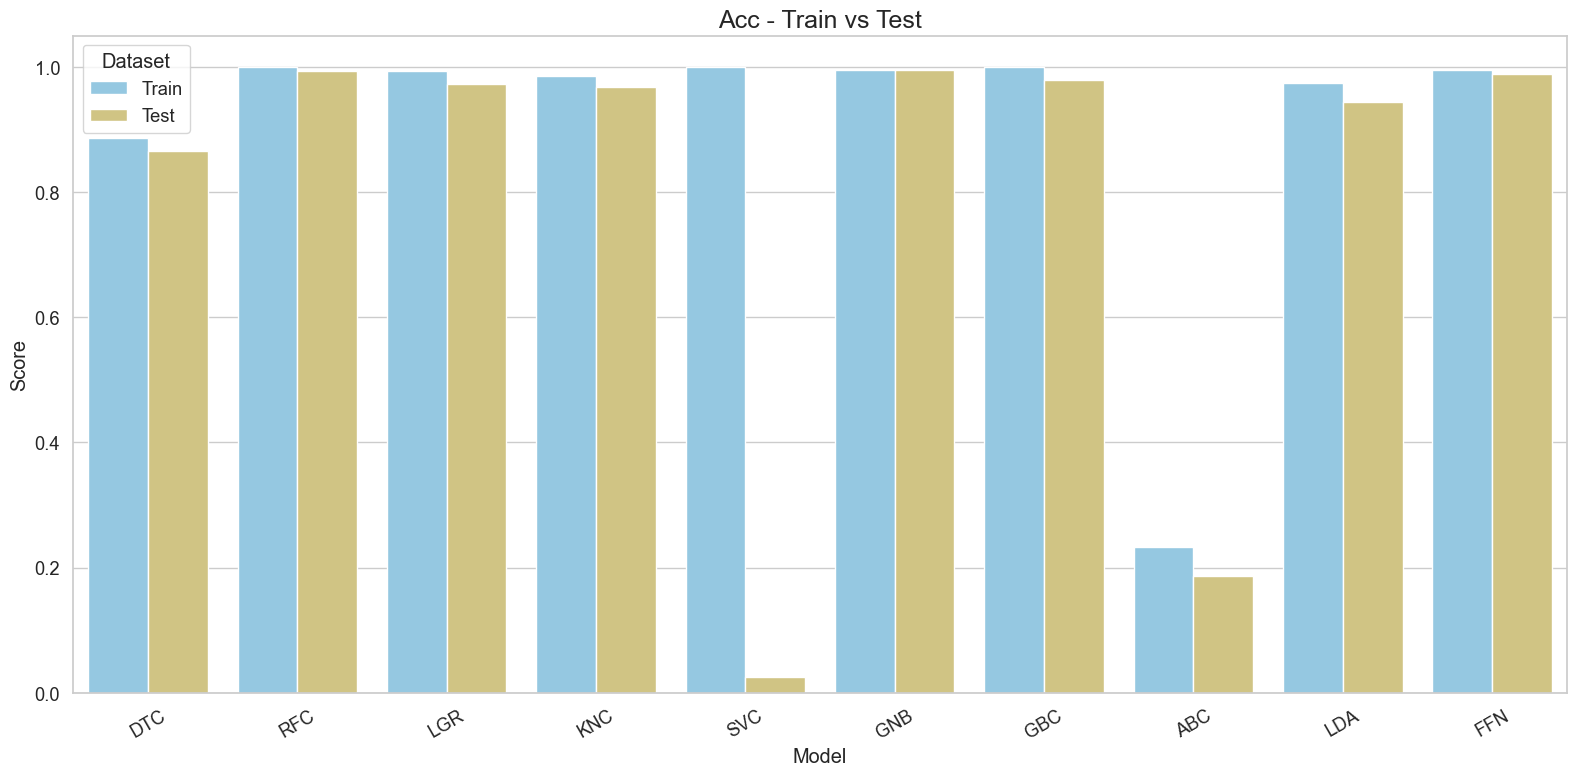

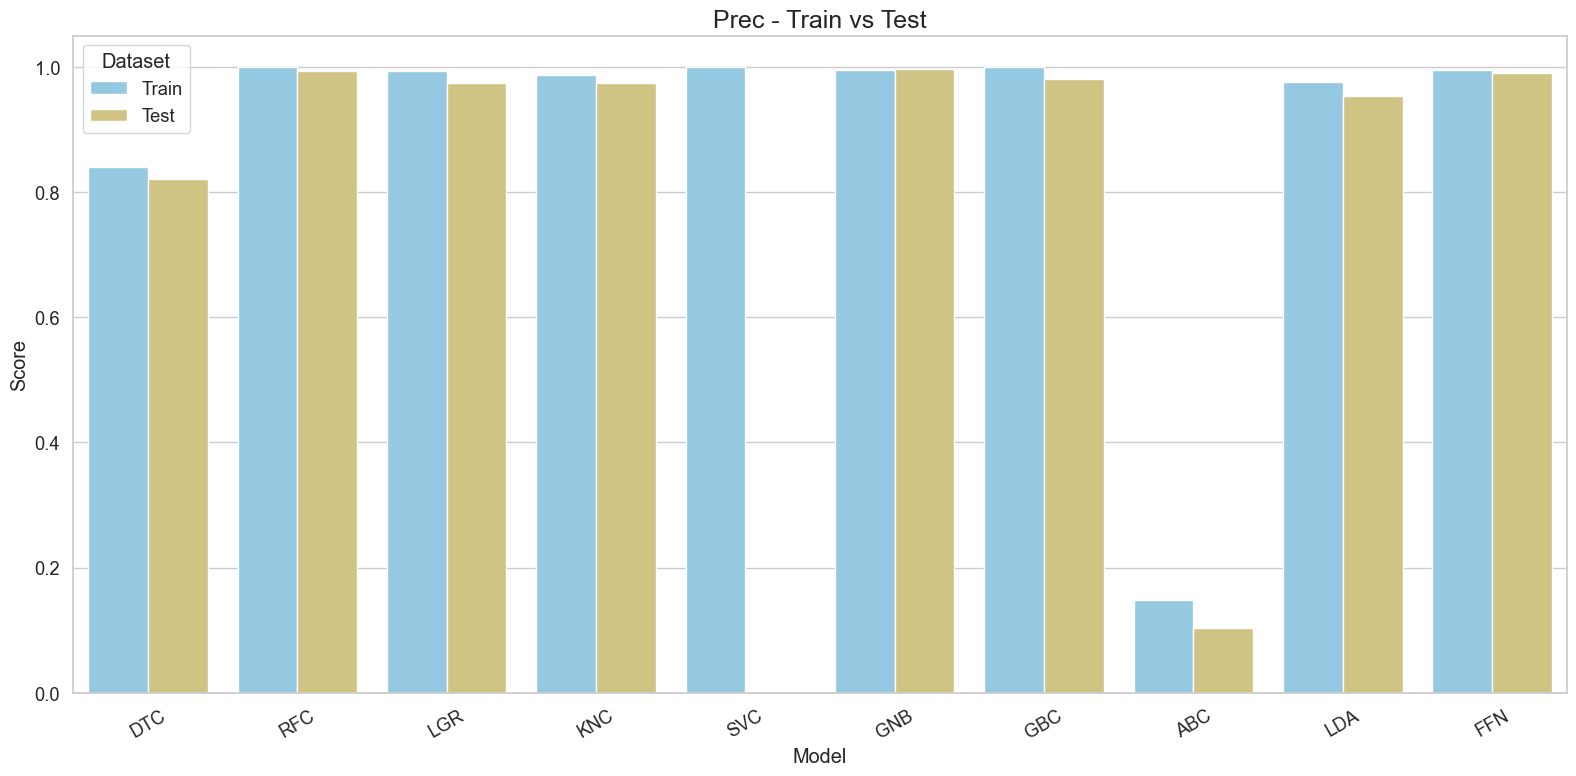

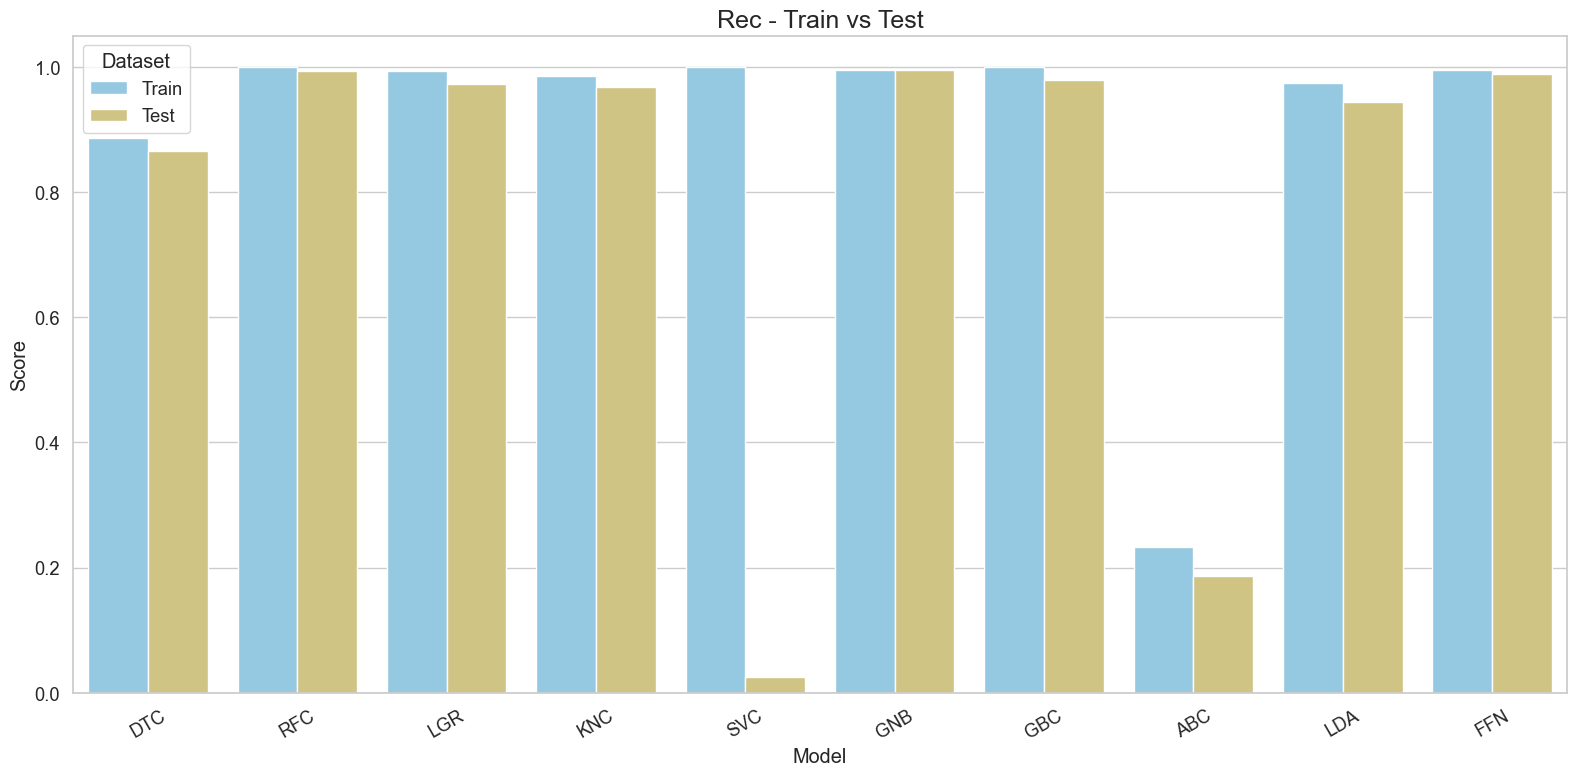

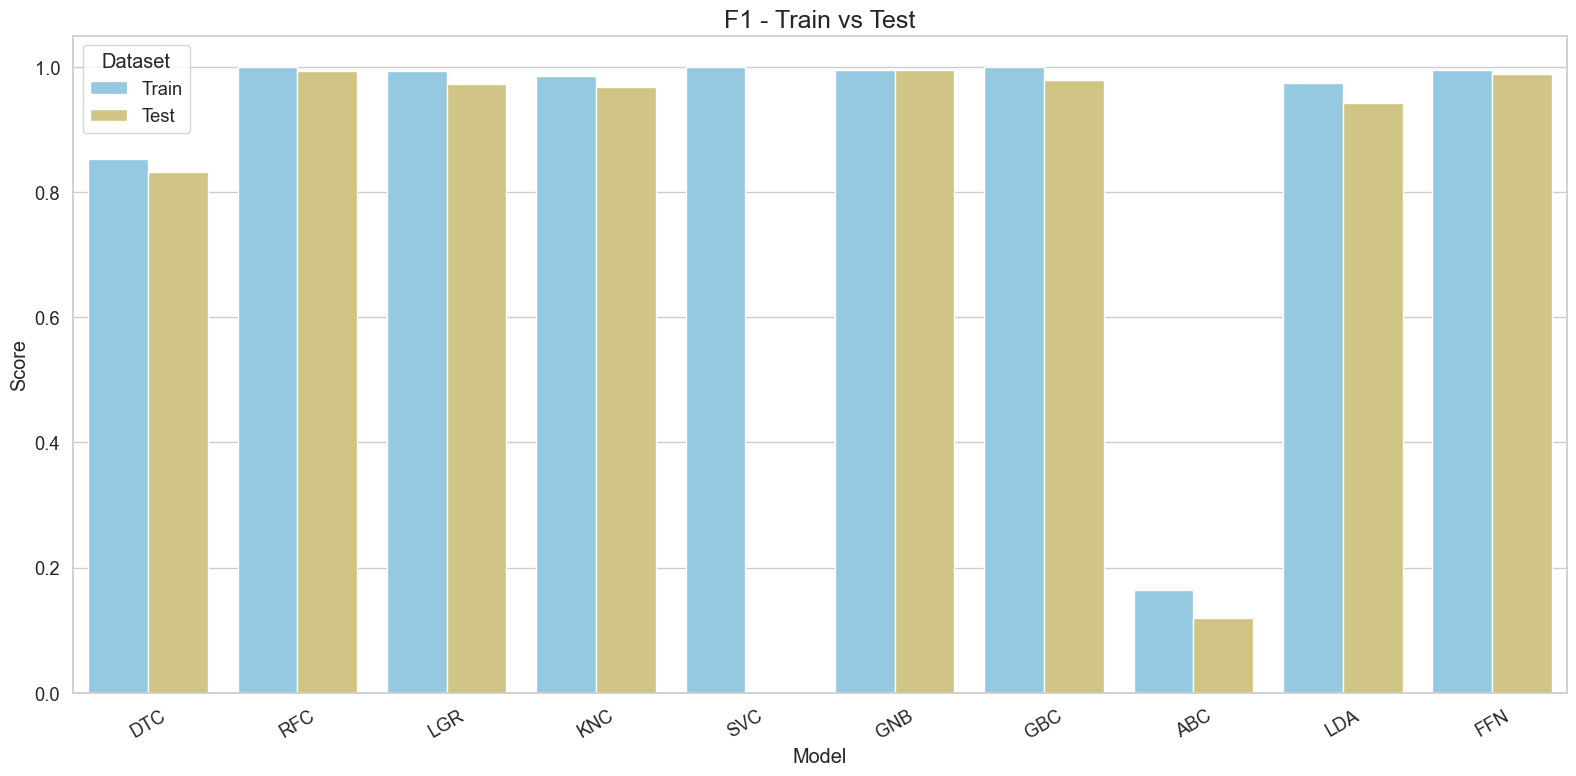

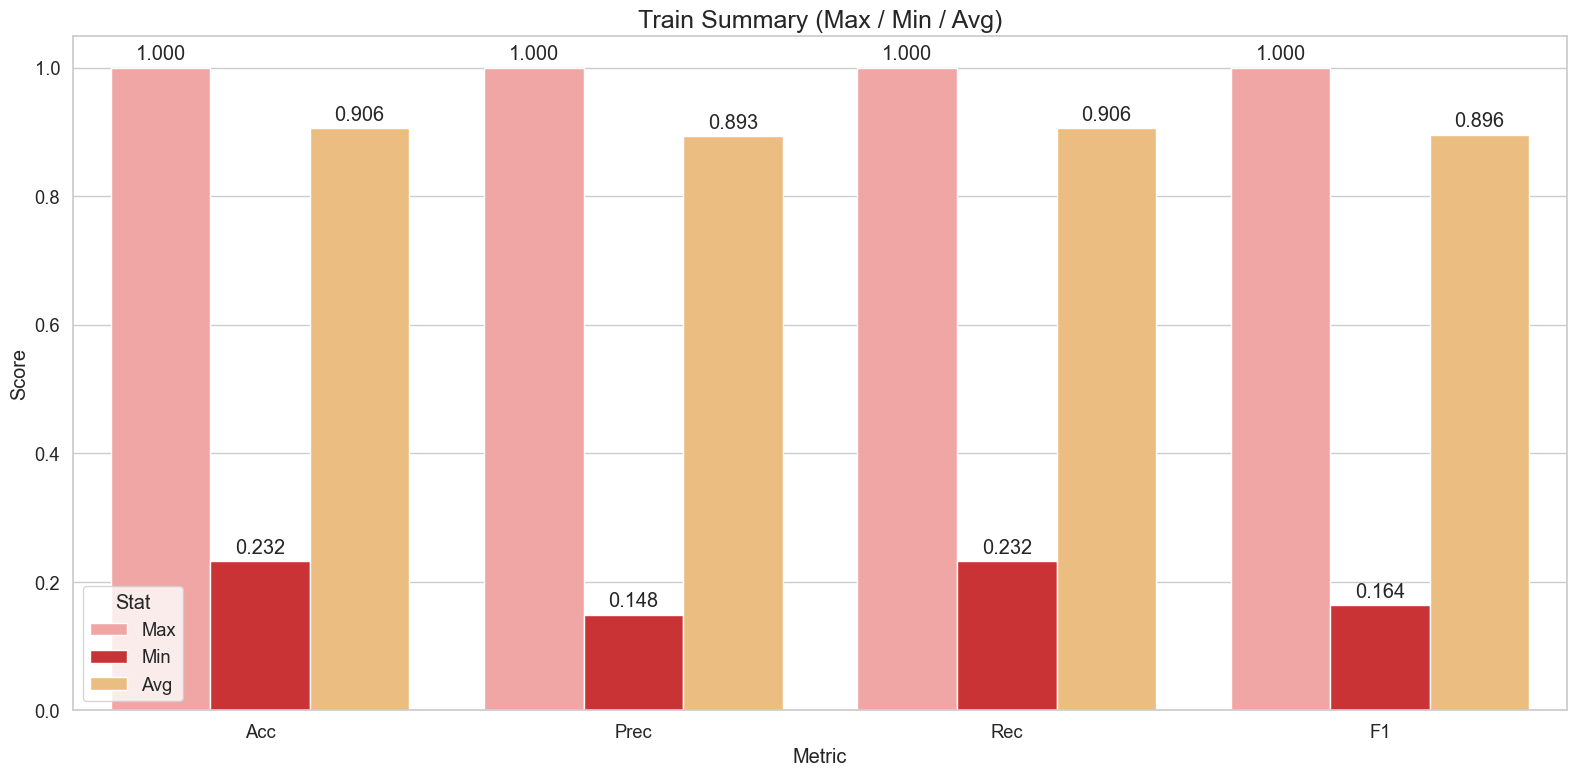

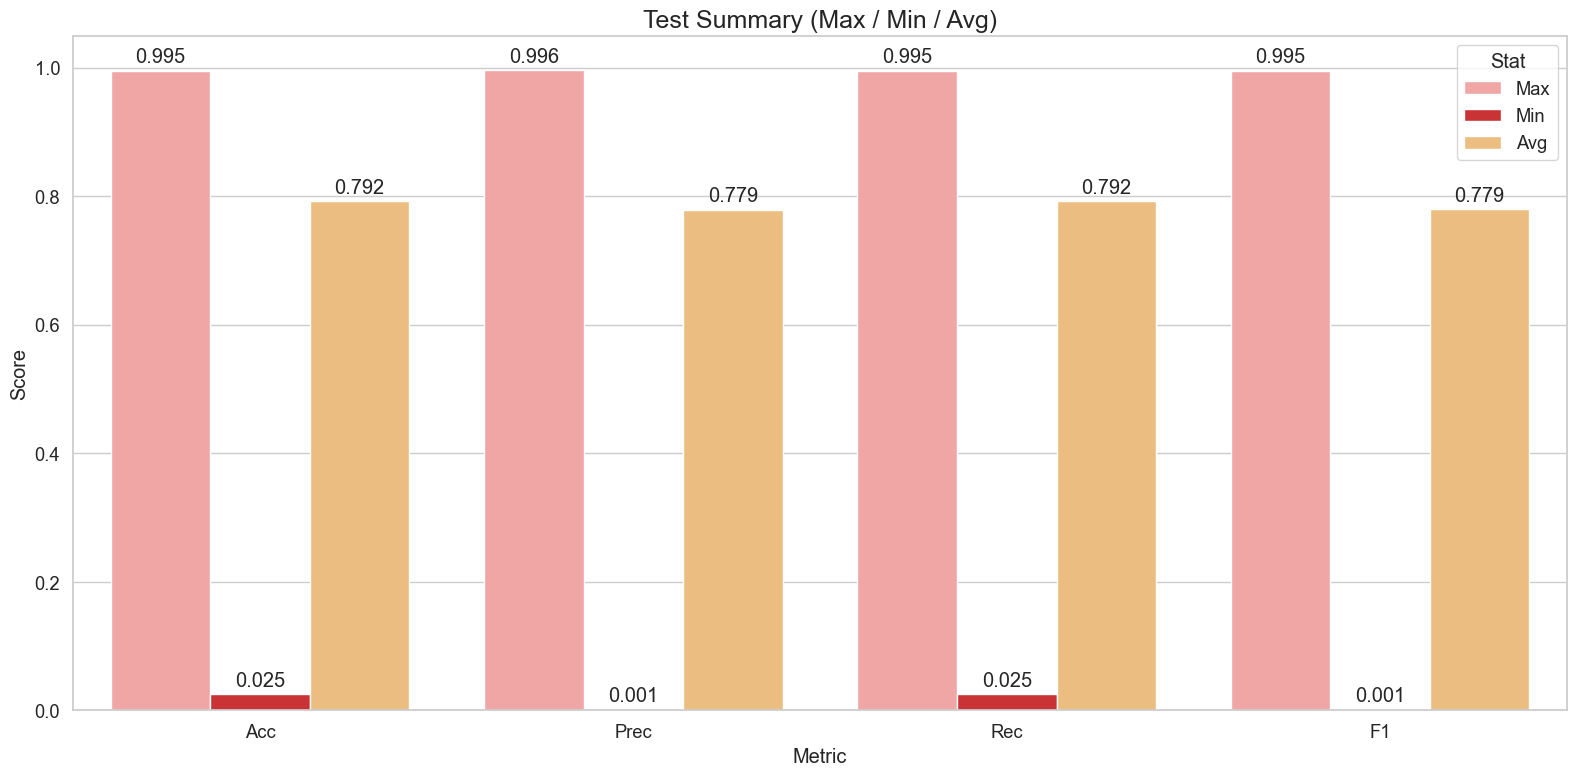

In [61]:
plot_model_metrics2(model_results)

In [62]:
def plot_model_metrics1(df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig, axes = plt.subplots(2, 3, figsize=(32, 20))
    axes = axes.flatten()

    palette_train = "#4DBBD5"
    palette_test  = "#E64B35"

    palette_summary = {
        "Max": "#3C5488",
        "Min": "#00A087",
        "Avg": "#F39B7F"
    }

    # -------- 1–4 METRIC PLOTS --------
    for i, m in enumerate(metrics):

        df_long = df[['Model', f'Train_{m}', f'Test_{m}']].copy()
        df_long = df_long.melt('Model', var_name='Dataset', value_name='Score')
        df_long['Dataset'] = df_long['Dataset'].apply(lambda x: 'Train' if 'Train' in x else 'Test')

        ax = axes[i]

        models = df_long['Model'].unique()
        x = np.arange(len(models))

        train_vals = df_long[df_long.Dataset=='Train']['Score'].values
        test_vals = df_long[df_long.Dataset=='Test']['Score'].values

        # lollipop stems
        ax.vlines(x-0.15, 0, train_vals, color=palette_train, lw=4, alpha=0.4)
        ax.vlines(x+0.15, 0, test_vals, color=palette_test, lw=4, alpha=0.4)

        # scatter heads
        ax.scatter(x-0.15, train_vals, s=250, color=palette_train, edgecolor='black', zorder=3, label="Train")
        ax.scatter(x+0.15, test_vals, s=250, color=palette_test, edgecolor='black', zorder=3, label="Test")

        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=30)

        ax.set_ylim(0,1.05)
        ax.set_title(f'{m} - Train vs Test', fontsize=18)

        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend()

    # -------- TRAIN SUMMARY --------
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })

    summary_train = pd.DataFrame(summary_list)

    ax = axes[4]

    x = np.arange(len(metrics))

    for stat in ['Max','Min','Avg']:
        vals = summary_train[stat].values
        ax.plot(x, vals, marker='o', markersize=12,
                linewidth=4,
                label=stat,
                color=palette_summary[stat])

        for i_val, v in enumerate(vals):
            ax.text(i_val, v+0.015, f"{v:.3f}", ha='center', fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0,1.05)
    ax.set_title('Train Summary (Max / Min / Avg)', fontsize=18)
    ax.legend()

    ax.grid(True, linestyle='--', alpha=0.3)


    # -------- TEST SUMMARY --------
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })

    summary_test = pd.DataFrame(summary_list)

    ax = axes[5]

    x = np.arange(len(metrics))

    for stat in ['Max','Min','Avg']:
        vals = summary_test[stat].values
        ax.plot(x, vals, marker='o', markersize=12,
                linewidth=4,
                label=stat,
                color=palette_summary[stat])

        for i_val, v in enumerate(vals):
            ax.text(i_val, v+0.015, f"{v:.3f}", ha='center', fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0,1.05)
    ax.set_title('Test Summary (Max / Min / Avg)', fontsize=18)
    ax.legend()

    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig("plot_model_metrics3.jpg", dpi=1000, bbox_inches="tight")
    plt.show()

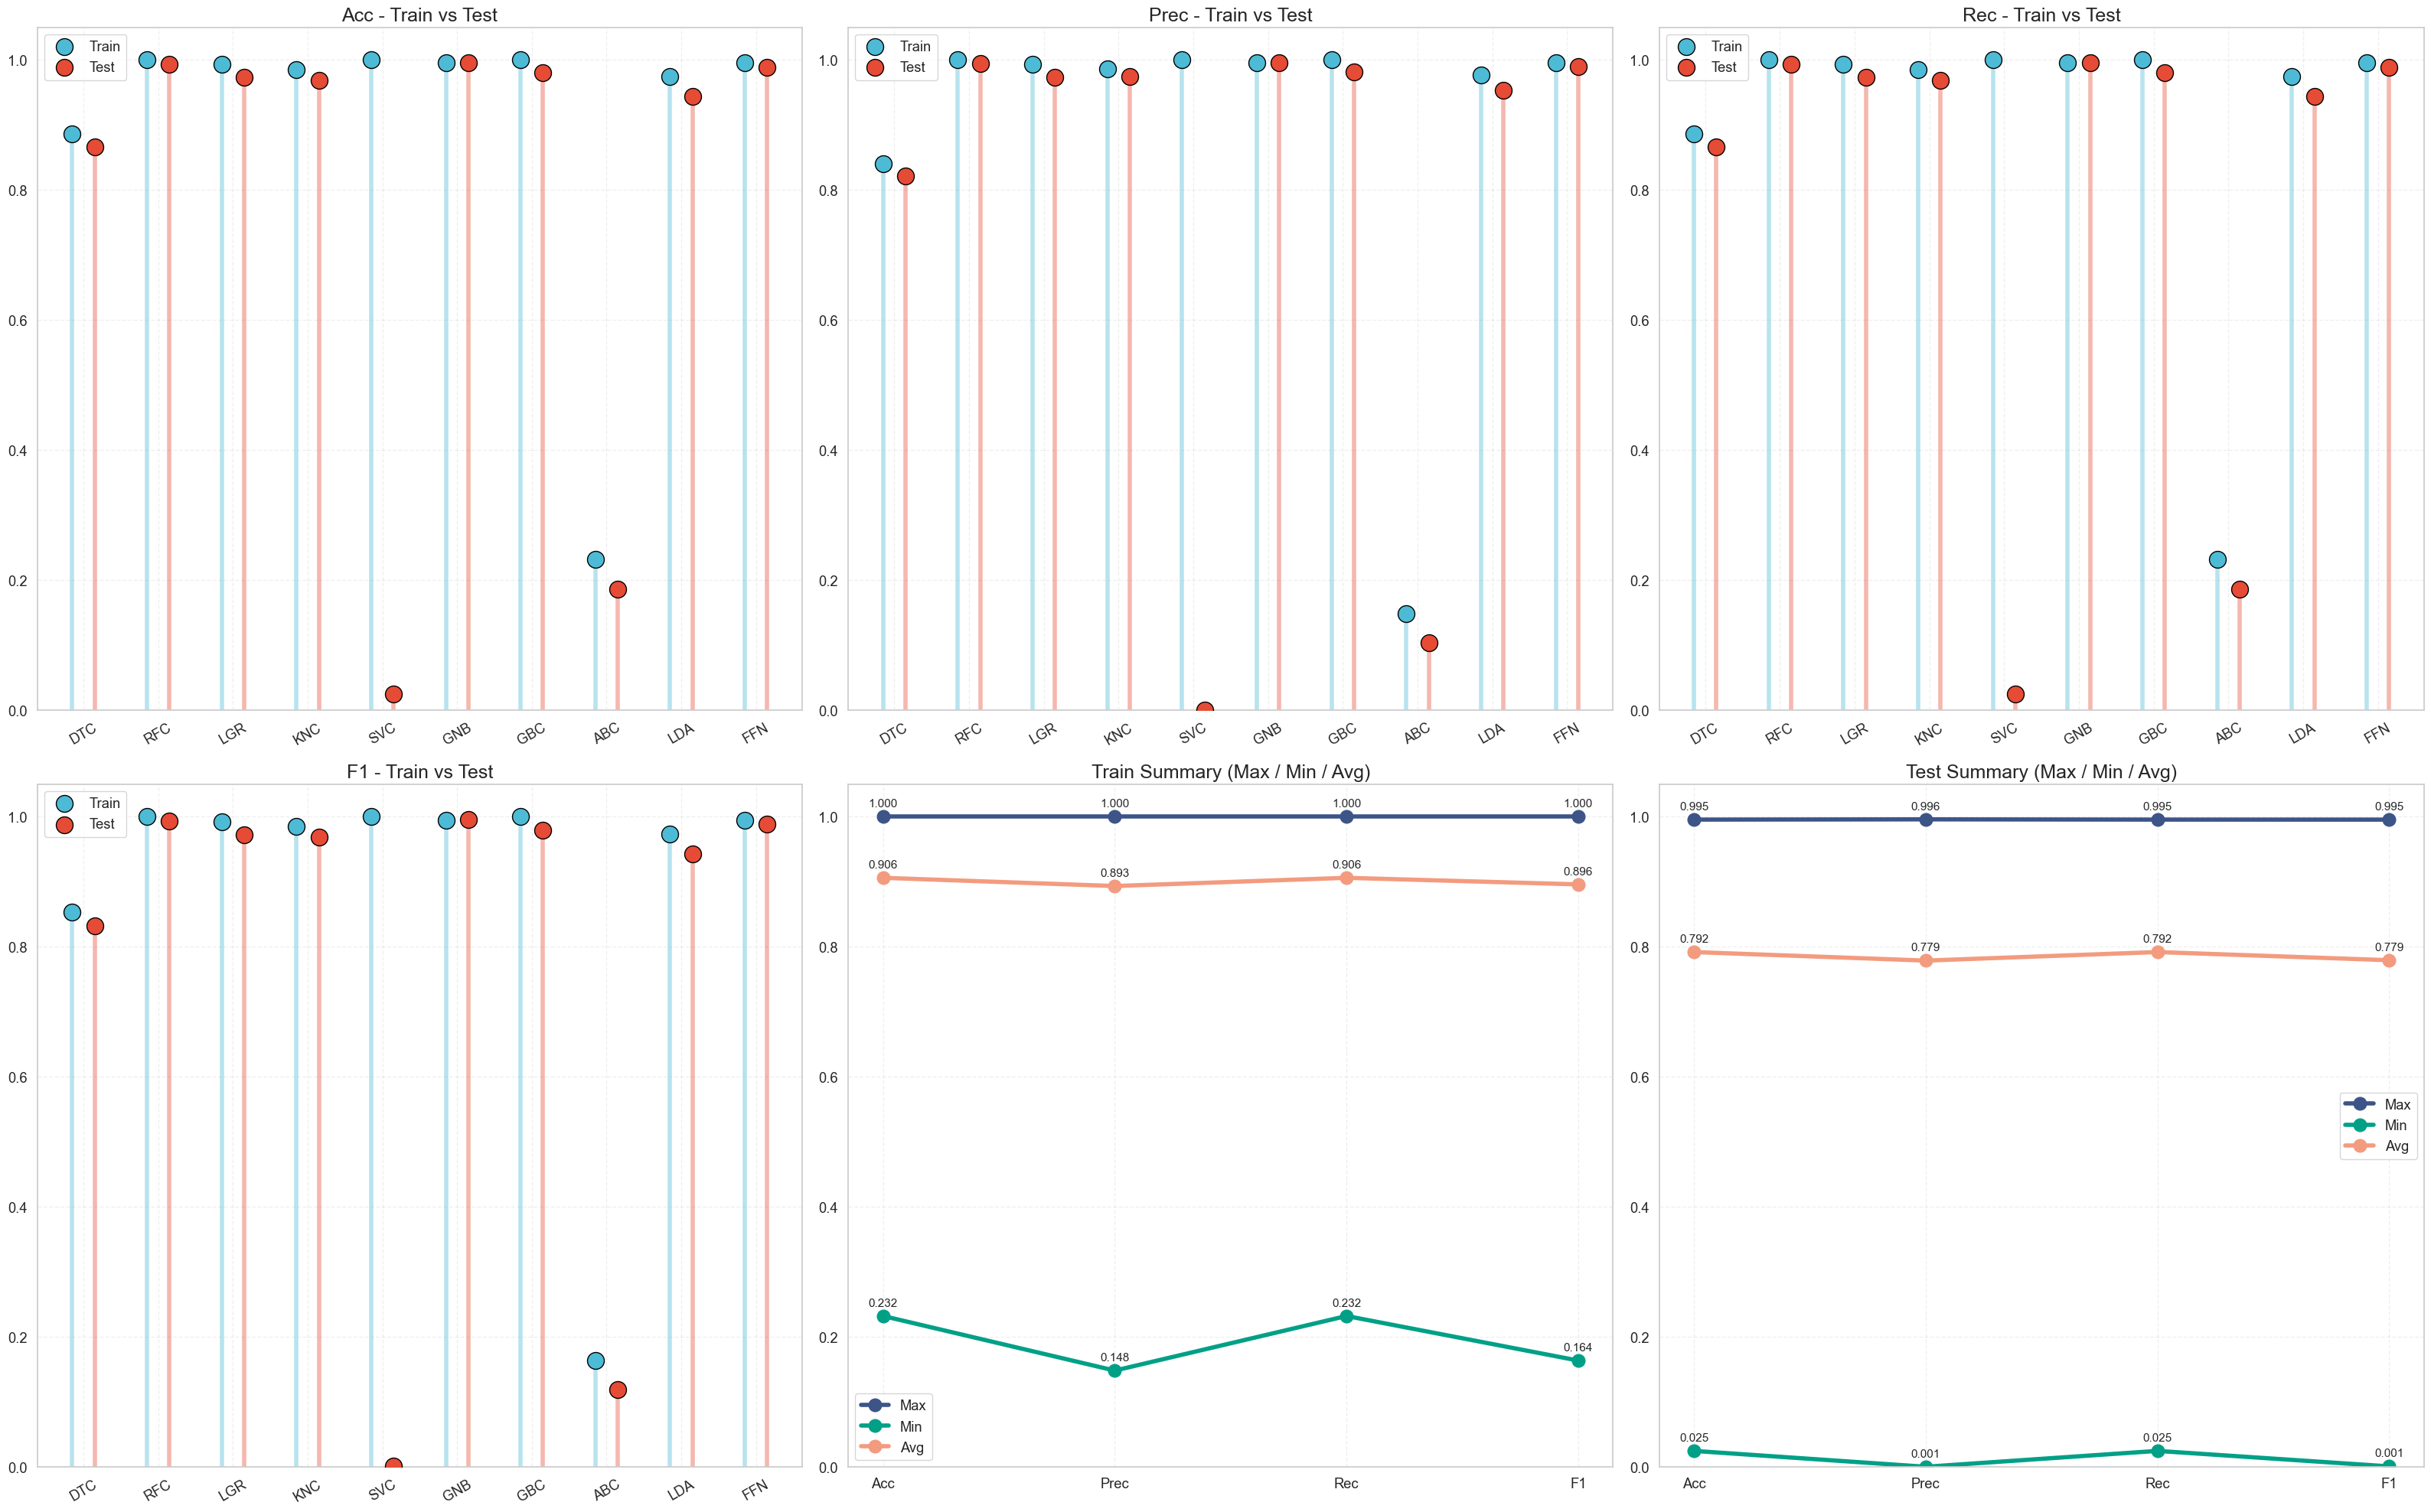

In [63]:
plot_model_metrics1(model_results)

In [64]:
def plot_model_metrics1(df):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig = plt.figure(figsize=(32,20))
    axes = [plt.subplot(2,3,i+1, projection='polar') if i<4 else plt.subplot(2,3,i+1) for i in range(6)]

    train_color = "#00c2ff"
    test_color = "#ff5e78"

    glow_train = "#a6ecff"
    glow_test = "#ffc1cc"

    # -------------------------
    # 1–4 RADIAL MODEL PLOTS
    # -------------------------

    for i, m in enumerate(metrics):

        ax = axes[i]

        train_vals = df[f'Train_{m}'].values
        test_vals = df[f'Test_{m}'].values

        models = df['Model'].values
        angles = np.linspace(0,2*np.pi,len(models),endpoint=False)

        train_vals = np.append(train_vals,train_vals[0])
        test_vals = np.append(test_vals,test_vals[0])
        angles = np.append(angles,angles[0])

        # glow layer
        ax.plot(angles,train_vals,color=glow_train,linewidth=12,alpha=0.25)
        ax.plot(angles,test_vals,color=glow_test,linewidth=12,alpha=0.25)

        # main layer
        ax.plot(angles,train_vals,color=train_color,linewidth=3,label="Train")
        ax.plot(angles,test_vals,color=test_color,linewidth=3,label="Test")

        ax.scatter(angles,train_vals,s=180,color=train_color,edgecolor="black",zorder=3)
        ax.scatter(angles,test_vals,s=180,color=test_color,edgecolor="black",zorder=3)

        ax.set_ylim(0,1.05)
        ax.set_title(f"{m} Comparison",fontsize=18,pad=20)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(models,fontsize=11)

        ax.legend(loc="upper right")

    # -------------------------
    # TRAIN SUMMARY DONUT
    # -------------------------

    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })

    summary_train = pd.DataFrame(summary_list)

    ax = axes[4]

    sizes = [
        summary_train['Max'].mean(),
        summary_train['Min'].mean(),
        summary_train['Avg'].mean()
    ]

    labels = ["Max","Min","Avg"]

    colors = ["#ff6b6b","#4ecdc4","#ffe66d"]

    wedges,texts,autotexts = ax.pie(
        sizes,
        labels=labels,
        autopct='%0.3f',
        startangle=90,
        colors=colors,
        pctdistance=0.8,
        wedgeprops=dict(width=0.45)
    )

    ax.set_title("Train Summary (Max / Min / Avg)",fontsize=18)


    # -------------------------
    # TEST SUMMARY DONUT
    # -------------------------

    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })

    summary_test = pd.DataFrame(summary_list)

    ax = axes[5]

    sizes = [
        summary_test['Max'].mean(),
        summary_test['Min'].mean(),
        summary_test['Avg'].mean()
    ]

    labels = ["Max","Min","Avg"]

    colors = ["#ff6b6b","#4ecdc4","#ffe66d"]

    wedges,texts,autotexts = ax.pie(
        sizes,
        labels=labels,
        autopct='%0.3f',
        startangle=90,
        colors=colors,
        pctdistance=0.8,
        wedgeprops=dict(width=0.45)
    )

    ax.set_title("Test Summary (Max / Min / Avg)",fontsize=18)

    plt.tight_layout()
    plt.savefig("plot_model_metrics2.jpg",dpi=1000,bbox_inches="tight")
    plt.show()

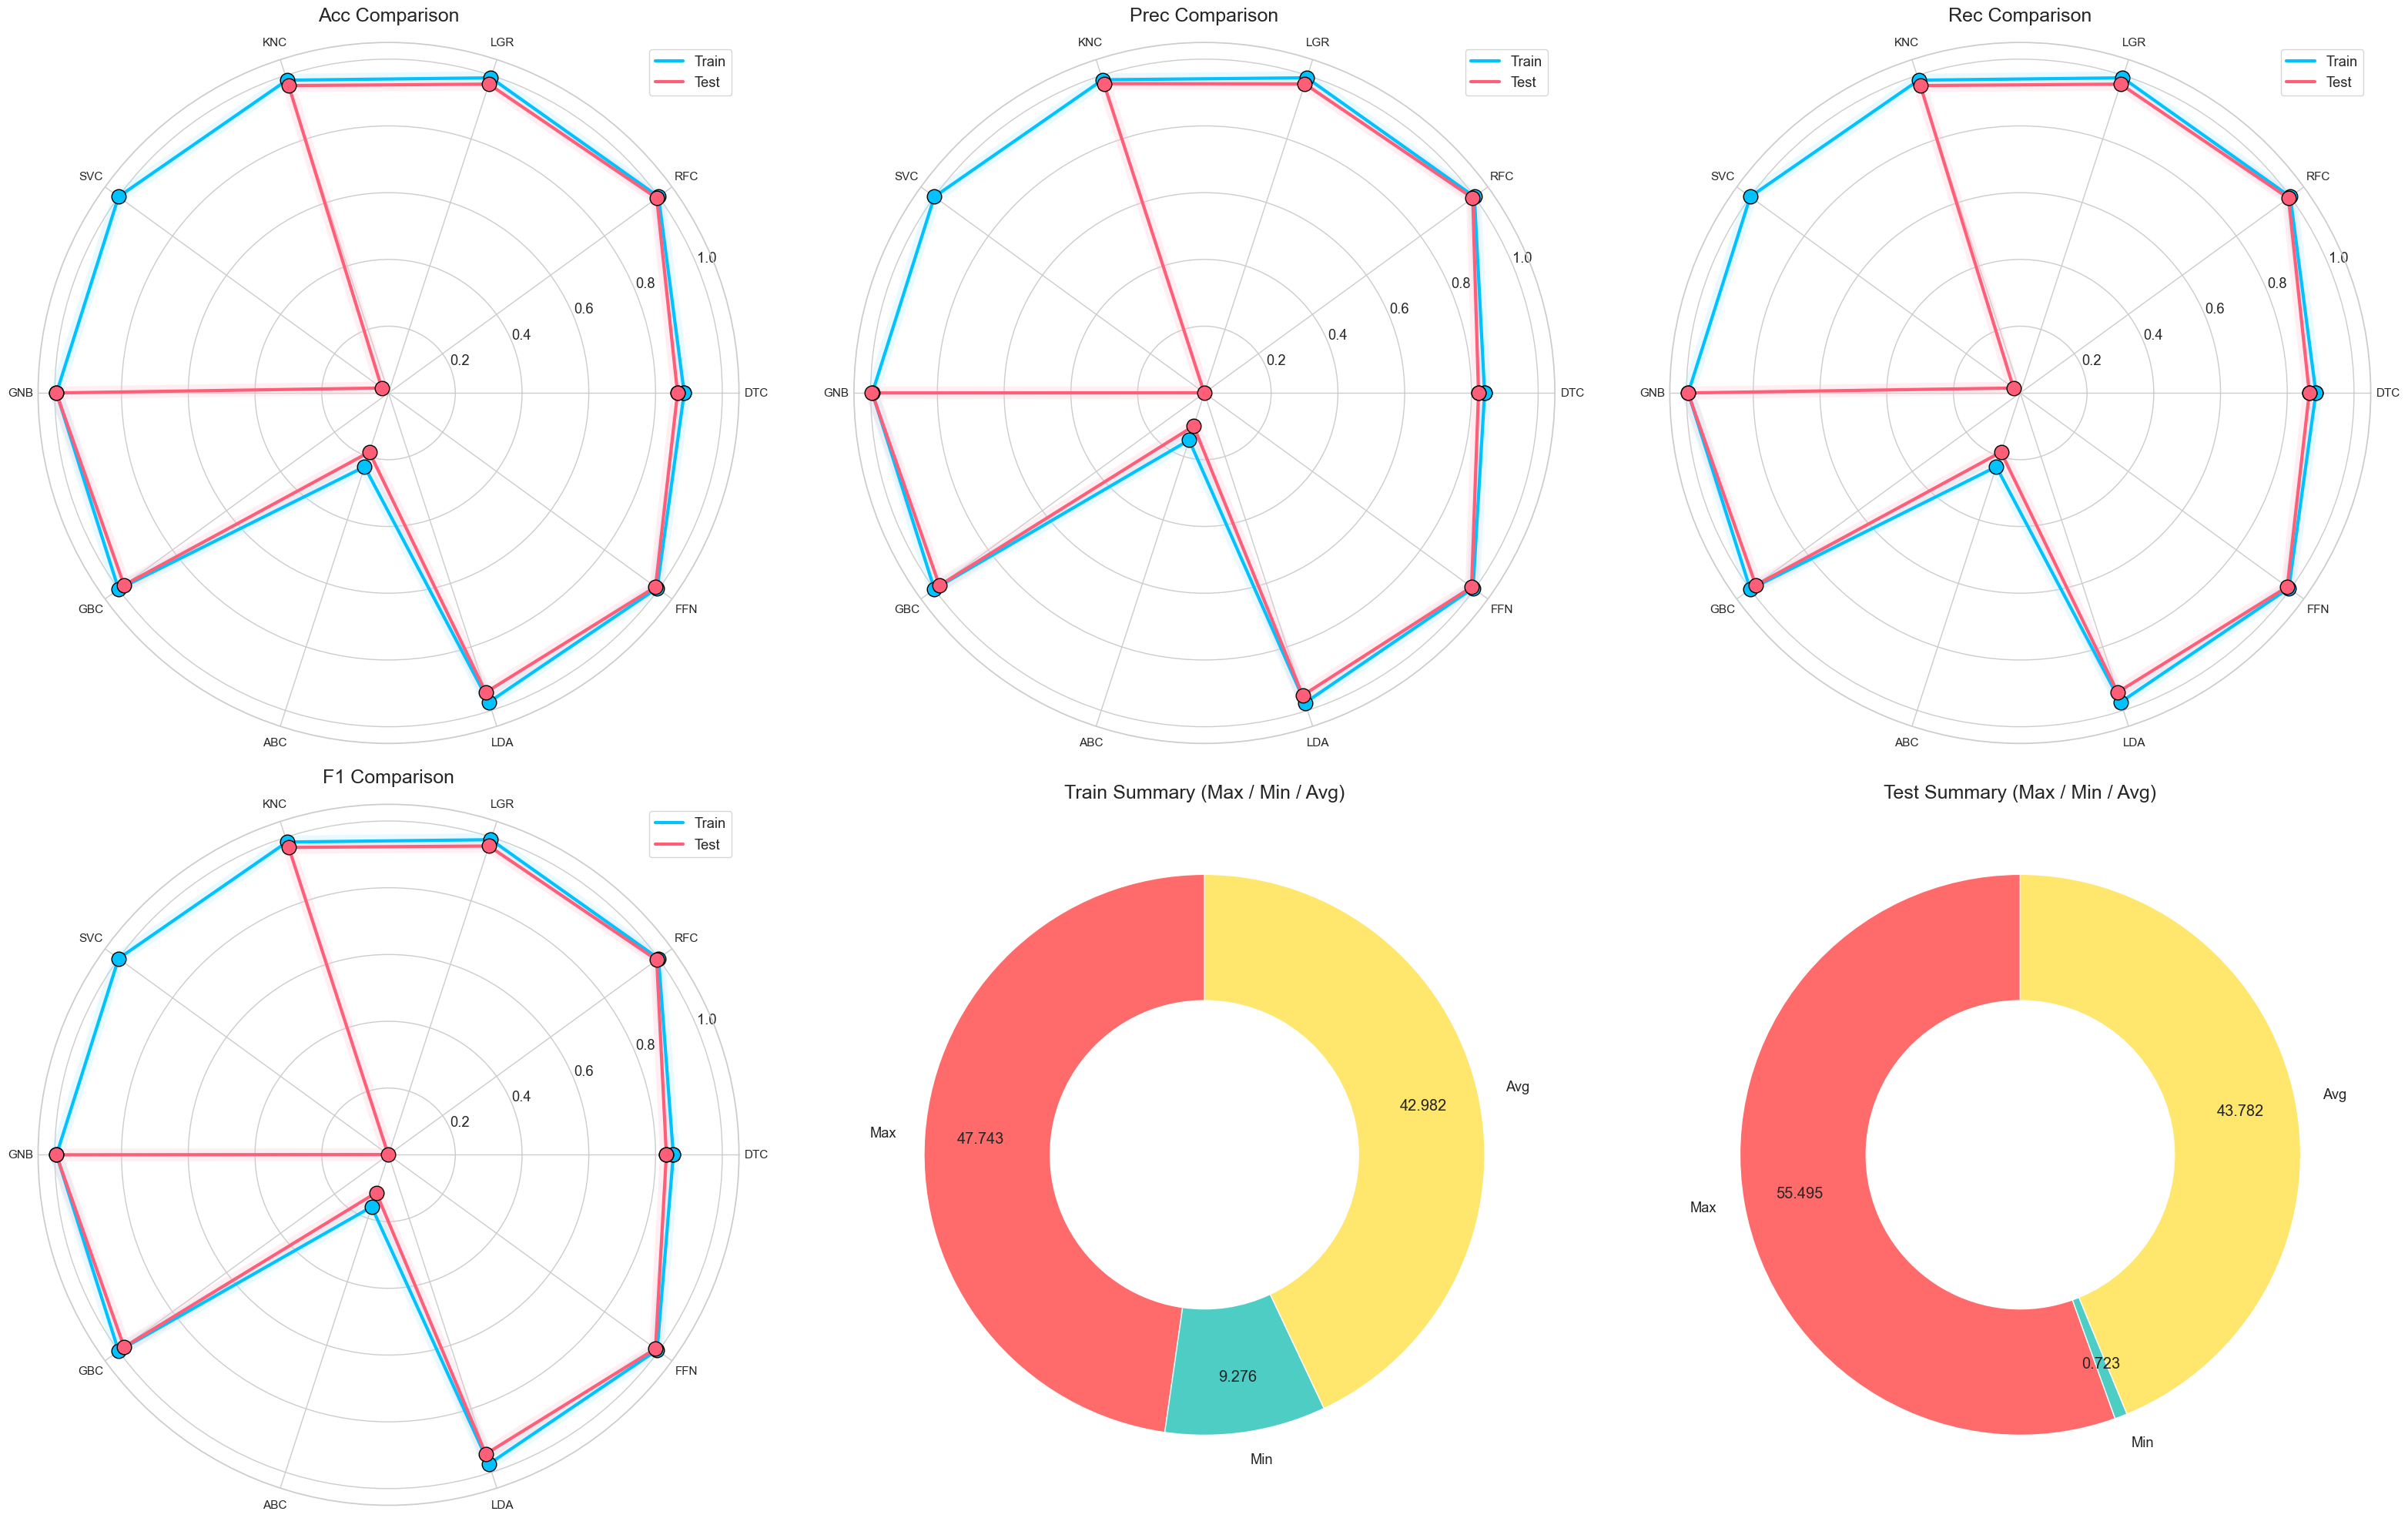

In [65]:
plot_model_metrics1(model_results)

In [66]:
def plot_model_metrics1(df):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc','Prec','Rec','F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig, axes = plt.subplots(2,3,figsize=(32,20))
    ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

    models = df['Model'].values
    x = np.arange(len(models))

    # ------------------------------------------------
    # 1 RADAR CHART (Average metric comparison)
    # ------------------------------------------------

    ax1.remove()
    ax1 = fig.add_subplot(2,3,1, projection='polar')

    train_avg = [df[f'Train_{m}'].mean() for m in metrics]
    test_avg  = [df[f'Test_{m}'].mean() for m in metrics]

    angles = np.linspace(0,2*np.pi,len(metrics),endpoint=False)

    train_avg += train_avg[:1]
    test_avg += test_avg[:1]
    angles = np.append(angles,angles[0])

    ax1.plot(angles,train_avg,linewidth=3,label="Train",color="#00c2ff")
    ax1.fill(angles,train_avg,alpha=0.25,color="#00c2ff")

    ax1.plot(angles,test_avg,linewidth=3,label="Test",color="#ff6b6b")
    ax1.fill(angles,test_avg,alpha=0.25,color="#ff6b6b")

    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(metrics)
    ax1.set_ylim(0,1)
    ax1.set_title("Metric Radar Comparison",fontsize=18)
    ax1.legend()


    # ------------------------------------------------
    # 2 BUBBLE SCATTER
    # ------------------------------------------------

    train_acc = df['Train_Acc']
    test_acc = df['Test_Acc']

    sizes = (train_acc + test_acc)*800

    ax2.scatter(train_acc,test_acc,
                s=sizes,
                c=train_acc,
                cmap="viridis",
                alpha=0.7,
                edgecolors="black")

    for i,m in enumerate(models):
        ax2.text(train_acc[i],test_acc[i],m,ha='center',va='center')

    ax2.set_xlabel("Train Accuracy")
    ax2.set_ylabel("Test Accuracy")
    ax2.set_title("Train vs Test Accuracy Bubble Plot",fontsize=18)


    # ------------------------------------------------
    # 3 HEATMAP
    # ------------------------------------------------

    heat_df = df.set_index("Model")[
        [f'Train_{m}' for m in metrics] +
        [f'Test_{m}' for m in metrics]
    ]

    sns.heatmap(
        heat_df,
        cmap="coolwarm",
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        ax=ax3
    )

    ax3.set_title("Model Performance Heatmap",fontsize=18)


    # ------------------------------------------------
    # 4 LOLLIPOP PLOT
    # ------------------------------------------------

    metric = "F1"

    train_vals = df[f'Train_{metric}']
    test_vals = df[f'Test_{metric}']

    ax4.vlines(x-0.1,0,train_vals,color="#00c2ff",lw=5,alpha=0.6)
    ax4.vlines(x+0.1,0,test_vals,color="#ff6b6b",lw=5,alpha=0.6)

    ax4.scatter(x-0.1,train_vals,s=200,color="#00c2ff",edgecolor="black",label="Train")
    ax4.scatter(x+0.1,test_vals,s=200,color="#ff6b6b",edgecolor="black",label="Test")

    ax4.set_xticks(x)
    ax4.set_xticklabels(models,rotation=30)
    ax4.set_ylim(0,1.05)

    ax4.set_title("F1 Score Comparison",fontsize=18)
    ax4.legend()


    # ------------------------------------------------
    # 5 DONUT CHART (TRAIN SUMMARY)
    # ------------------------------------------------

    train_stats = [
        max(df['Train_Acc']),
        min(df['Train_Acc']),
        df['Train_Acc'].mean()
    ]

    labels = ["Max","Min","Avg"]

    wedges,_,_ = ax5.pie(
        train_stats,
        labels=labels,
        autopct='%0.3f',
        startangle=90,
        colors=["#ff6b6b","#4ecdc4","#ffe66d"],
        wedgeprops=dict(width=0.45)
    )

    ax5.set_title("Train Accuracy Summary",fontsize=18)


    # ------------------------------------------------
    # 6 RADIAL BAR CHART (TEST SUMMARY)
    # ------------------------------------------------

    ax6.remove()
    ax6 = fig.add_subplot(2,3,6, projection='polar')

    test_avg = [df[f'Test_{m}'].mean() for m in metrics]

    angles = np.linspace(0,2*np.pi,len(metrics),endpoint=False)

    bars = ax6.bar(
        angles,
        test_avg,
        width=0.4,
        color=plt.cm.plasma(test_avg),
        alpha=0.85
    )

    ax6.set_xticks(angles)
    ax6.set_xticklabels(metrics)

    ax6.set_ylim(0,1)

    ax6.set_title("Average Test Metrics Radial Bars",fontsize=18)

    plt.tight_layout()
    plt.savefig("plot_model_metrics4.jpg", dpi=1000, bbox_inches="tight")
    plt.show()

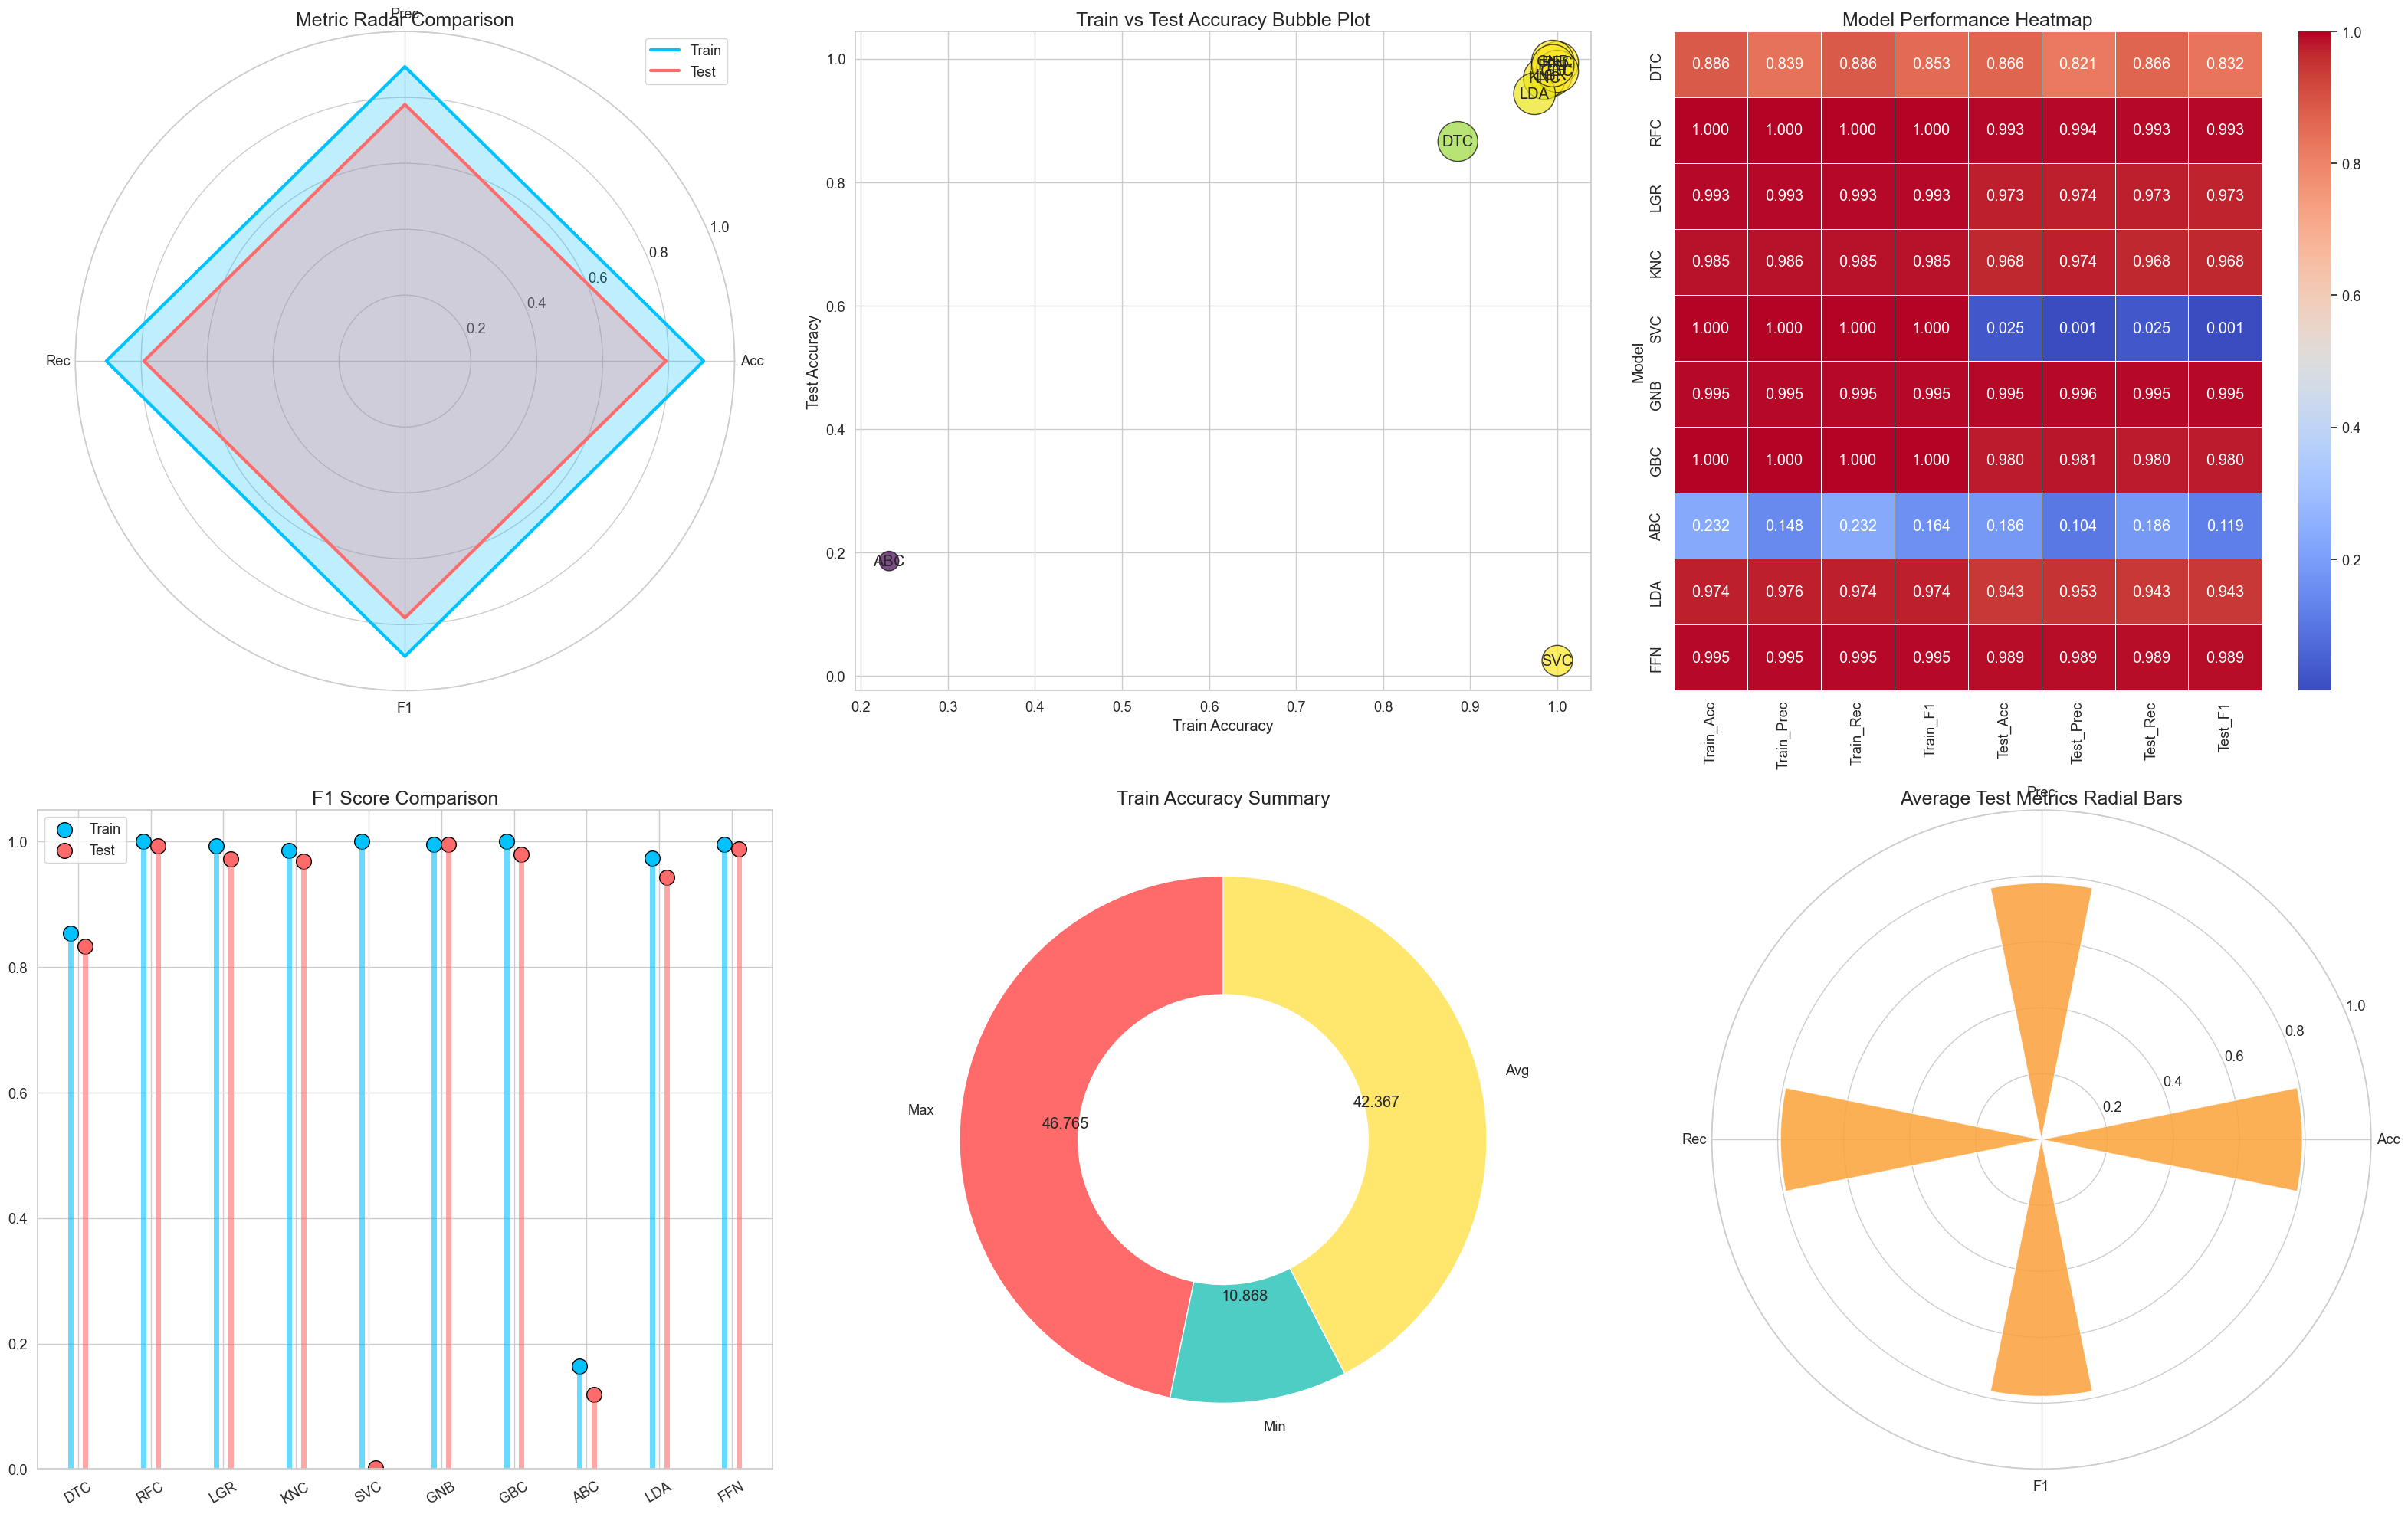

In [67]:
plot_model_metrics1(model_results)

In [68]:
def plot_model_metrics1(df):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc','Prec','Rec','F1']

    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(2,3,figsize=(32,20))
    ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

    # ------------------------------------------------
    # 1 Accuracy Train vs Test
    # ------------------------------------------------

    df_acc = df[['Model','Train_Acc','Test_Acc']].melt(
        id_vars="Model",
        var_name="Dataset",
        value_name="Score"
    )

    sns.barplot(
        data=df_acc,
        x="Model",
        y="Score",
        hue="Dataset",
        palette=["#4DBBD5","#E64B35"],
        ax=ax1
    )

    ax1.set_title("Accuracy: Train vs Test",fontsize=18)
    ax1.set_ylim(0,1.05)
    ax1.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 2 Precision Recall F1 Trend
    # ------------------------------------------------

    for m,color in zip(['Prec','Rec','F1'],["#00A087","#3C5488","#F39B7F"]):

        ax2.plot(
            df["Model"],
            df[f"Test_{m}"],
            marker="o",
            linewidth=3,
            label=m,
            color=color
        )

    ax2.set_ylim(0,1.05)
    ax2.set_title("Test Metric Trends Across Models",fontsize=18)
    ax2.tick_params(axis='x',rotation=30)
    ax2.legend()

    # ------------------------------------------------
    # 3 Overfitting Gap
    # ------------------------------------------------

    gap = df['Train_Acc'] - df['Test_Acc']

    colors = ["#2ECC71" if g<0.02 else "#E74C3C" for g in gap]

    ax3.bar(df["Model"],gap,color=colors)

    ax3.axhline(0,color="black",linewidth=1)

    ax3.set_title("Train-Test Accuracy Gap (Overfitting Indicator)",fontsize=18)
    ax3.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 4 Metric Distribution
    # ------------------------------------------------

    dist_df = df[[f'Train_{m}' for m in metrics]].copy()

    dist_df.columns = metrics

    sns.boxplot(
        data=dist_df,
        palette="Set2",
        ax=ax4
    )

    ax4.set_ylim(0,1.05)
    ax4.set_title("Distribution of Train Metrics",fontsize=18)

    # ------------------------------------------------
    # 5 Train Summary
    # ------------------------------------------------

    train_stats = pd.DataFrame({
        "Metric":metrics,
        "Max":[df[f"Train_{m}"].max() for m in metrics],
        "Min":[df[f"Train_{m}"].min() for m in metrics],
        "Avg":[df[f"Train_{m}"].mean() for m in metrics]
    }).melt(id_vars="Metric",var_name="Stat",value_name="Score")

    sns.barplot(
        data=train_stats,
        x="Metric",
        y="Score",
        hue="Stat",
        palette=["#E41A1C","#377EB8","#4DAF4A"],
        ax=ax5
    )

    ax5.set_ylim(0,1.05)
    ax5.set_title("Train Metric Summary",fontsize=18)

    for container in ax5.containers:
        ax5.bar_label(container,fmt="%.3f")

    # ------------------------------------------------
    # 6 Test Summary
    # ------------------------------------------------

    test_stats = pd.DataFrame({
        "Metric":metrics,
        "Max":[df[f"Test_{m}"].max() for m in metrics],
        "Min":[df[f"Test_{m}"].min() for m in metrics],
        "Avg":[df[f"Test_{m}"].mean() for m in metrics]
    }).melt(id_vars="Metric",var_name="Stat",value_name="Score")

    sns.barplot(
        data=test_stats,
        x="Metric",
        y="Score",
        hue="Stat",
        palette=["#E41A1C","#377EB8","#4DAF4A"],
        ax=ax6
    )

    ax6.set_ylim(0,1.05)
    ax6.set_title("Test Metric Summary",fontsize=18)

    for container in ax6.containers:
        ax6.bar_label(container,fmt="%.3f")

    plt.tight_layout()
    plt.savefig("plot_model_metrics6.jpg",dpi=1000,bbox_inches="tight")
    plt.show()

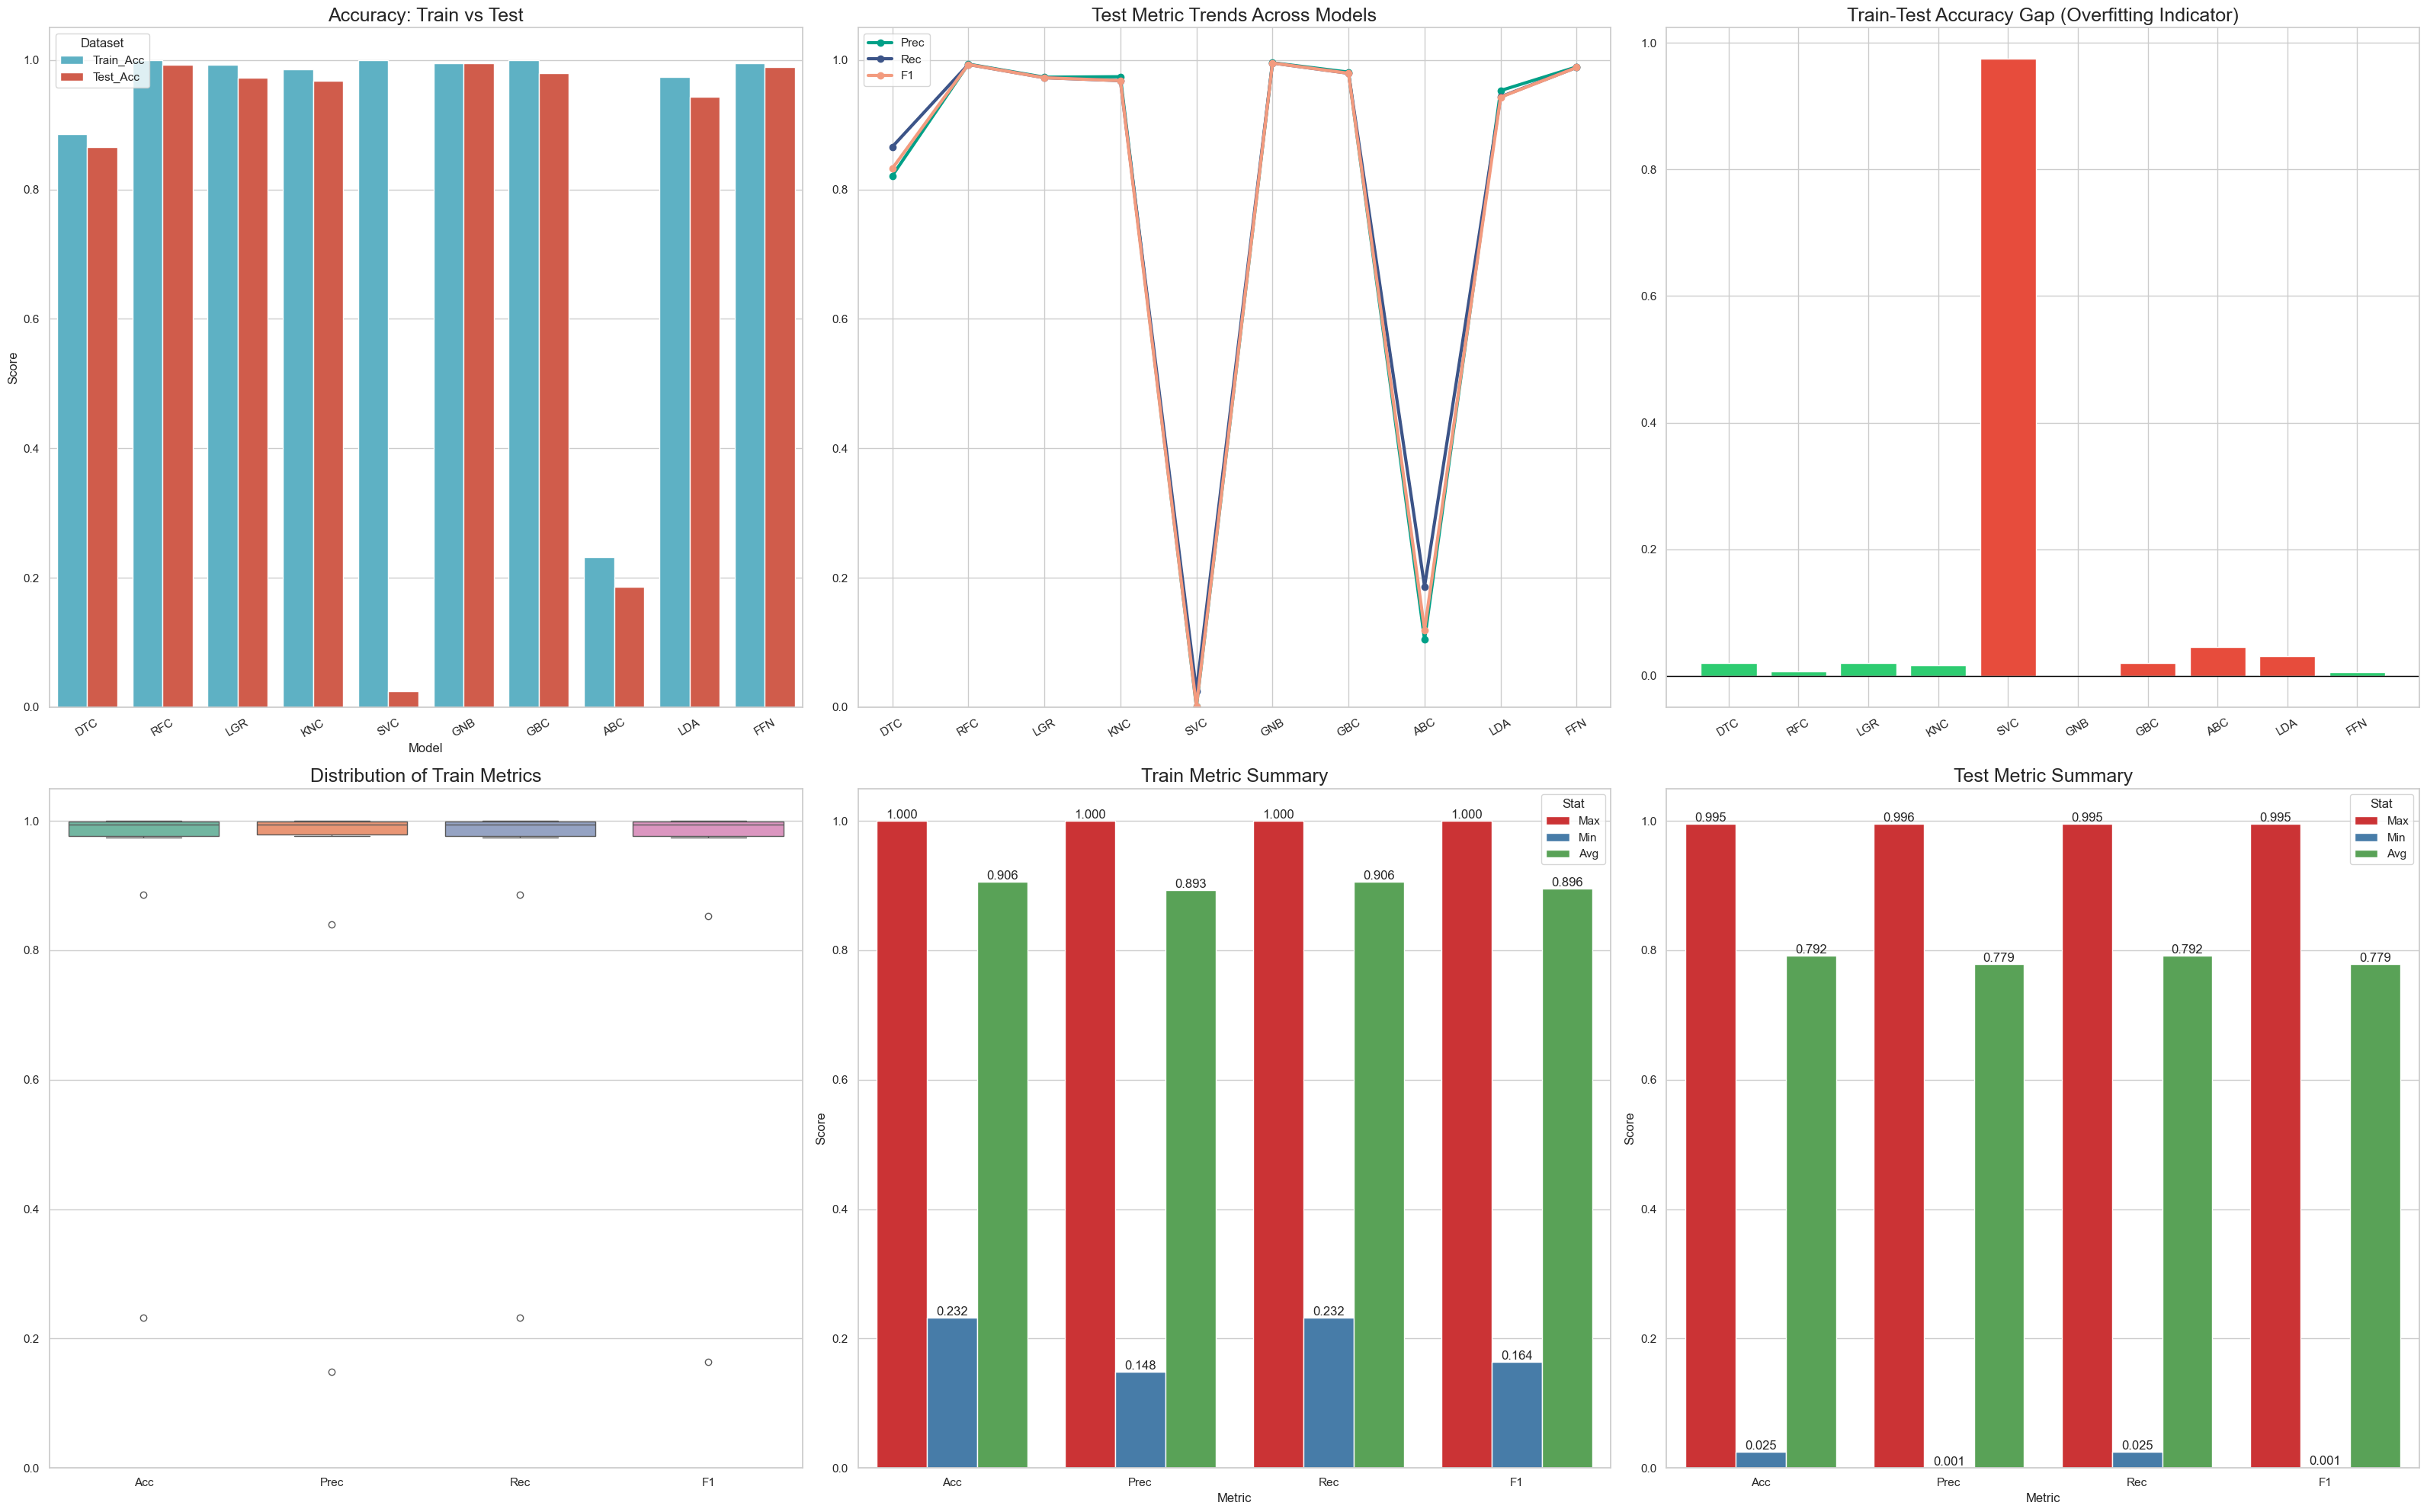

In [69]:
plot_model_metrics1(model_results)

In [70]:
def plot_model_metrics1(df):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc','Prec','Rec','F1']

    sns.set_theme(style="whitegrid", font_scale=1.3)

    fig, axes = plt.subplots(2,3,figsize=(32,20))
    ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

    models = df["Model"]

    # ------------------------------------------------
    # 1 Train vs Test Accuracy
    # ------------------------------------------------

    df_acc = df[['Model','Train_Acc','Test_Acc']].melt(
        id_vars="Model",
        var_name="Dataset",
        value_name="Score"
    )

    sns.barplot(
        data=df_acc,
        x="Model",
        y="Score",
        hue="Dataset",
        palette=["#4DBBD5","#E64B35"],
        ax=ax1
    )

    ax1.set_title("Accuracy: Train vs Test",fontsize=20)
    ax1.set_ylim(0,1.05)
    ax1.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 2 Precision Recall F1 trend
    # ------------------------------------------------

    for m,c in zip(["Prec","Rec","F1"],["#00A087","#3C5488","#F39B7F"]):

        ax2.plot(
            models,
            df[f"Test_{m}"],
            marker="o",
            linewidth=4,
            markersize=10,
            label=m,
            color=c
        )

    ax2.set_ylim(0,1.05)
    ax2.set_title("Test Metric Comparison",fontsize=20)
    ax2.legend()
    ax2.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 3 Overfitting gap
    # ------------------------------------------------

    gap = df["Train_Acc"] - df["Test_Acc"]

    colors = ["#2ECC71" if g<0.02 else "#E74C3C" for g in gap]

    ax3.bar(models,gap,color=colors)

    ax3.axhline(0,color="black",linewidth=1)

    ax3.set_title("Train-Test Gap (Overfitting)",fontsize=20)
    ax3.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 4 Heatmap
    # ------------------------------------------------

    heat = df.set_index("Model")[
        [f'Train_{m}' for m in metrics] +
        [f'Test_{m}' for m in metrics]
    ]

    sns.heatmap(
        heat,
        cmap="viridis",
        annot=True,
        fmt=".3f",
        linewidths=0.6,
        ax=ax4
    )

    ax4.set_title("Model Performance Heatmap",fontsize=20)

    # ------------------------------------------------
    # 5 Train summary
    # ------------------------------------------------

    train_stats = pd.DataFrame({
        "Metric":metrics,
        "Max":[df[f"Train_{m}"].max() for m in metrics],
        "Min":[df[f"Train_{m}"].min() for m in metrics],
        "Avg":[df[f"Train_{m}"].mean() for m in metrics]
    }).melt(id_vars="Metric",var_name="Stat",value_name="Score")

    sns.barplot(
        data=train_stats,
        x="Metric",
        y="Score",
        hue="Stat",
        palette="Set2",
        ax=ax5
    )

    ax5.set_ylim(0,1.05)
    ax5.set_title("Train Summary",fontsize=20)

    for c in ax5.containers:
        ax5.bar_label(c,fmt="%.3f")

    # ------------------------------------------------
    # 6 Test summary
    # ------------------------------------------------

    test_stats = pd.DataFrame({
        "Metric":metrics,
        "Max":[df[f"Test_{m}"].max() for m in metrics],
        "Min":[df[f"Test_{m}"].min() for m in metrics],
        "Avg":[df[f"Test_{m}"].mean() for m in metrics]
    }).melt(id_vars="Metric",var_name="Stat",value_name="Score")

    sns.barplot(
        data=test_stats,
        x="Metric",
        y="Score",
        hue="Stat",
        palette="Set2",
        ax=ax6
    )

    ax6.set_ylim(0,1.05)
    ax6.set_title("Test Summary",fontsize=20)

    for c in ax6.containers:
        ax6.bar_label(c,fmt="%.3f")

    plt.tight_layout()
    plt.savefig("plot_model_metrics6.jpg",dpi=1000,bbox_inches="tight")
    plt.show()

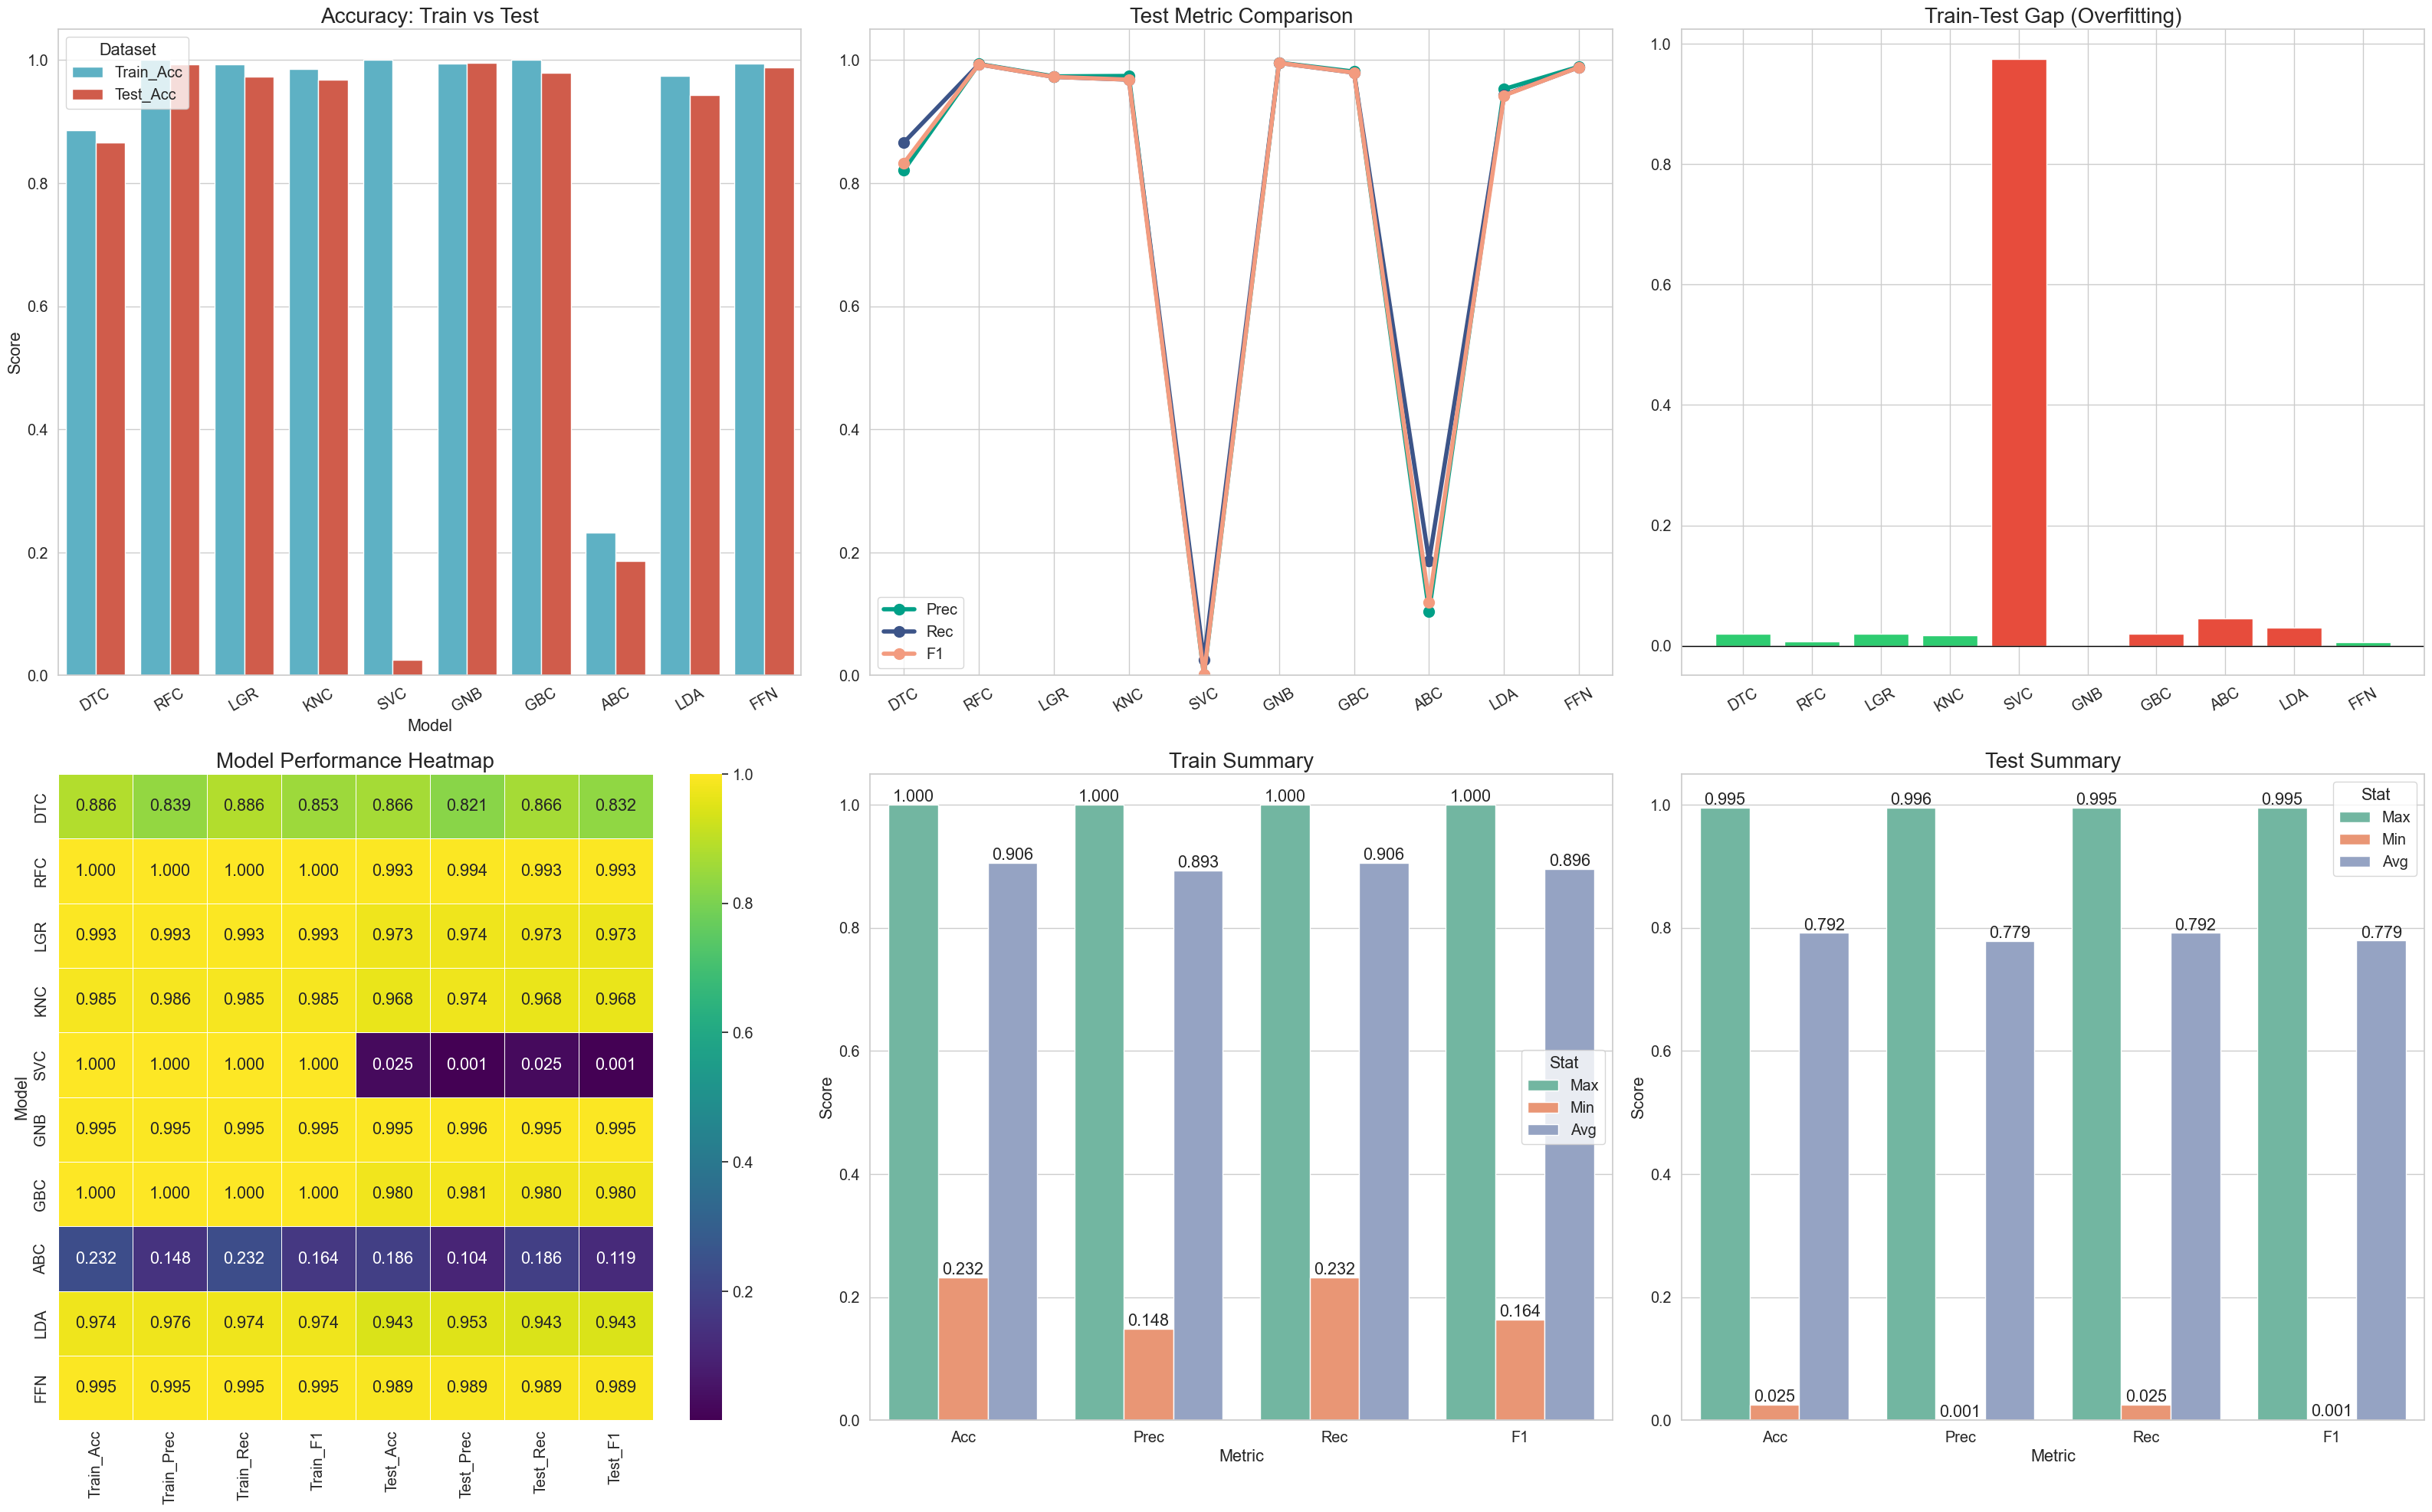

In [71]:
plot_model_metrics1(model_results)